![Project Diagram](Violence_image.jpeg)

# Predicting the Severity of Political Violence in Kenya
*A Machine Learning Approach Using Historical Conflict Fatality Data*

---
**Team:**(Ctrl-Alt-Elite)  
**Contributors:** Kimutai Kevine, Mercy Wambui, Jackline Mwau, Richard Oketch, Winnie Nduva, Reeves Gonah  
**Date:** June - July 2026  
**Project:** Capstone Project  
**Data Sources:** [ACLED Africa Aggregated Conflict Dataset](https://acleddata.com/aggregated/aggregated-data-africa) | [WorldPop Population-Weighted Density Dataset](https://hub.worldpop.org/geodata/summary?id=50573)

---


## Abstract

This notebook documents the end-to-end pipeline for predicting the severity of political violence — measured as fatality counts — across Kenya's 47 counties at weekly resolution. The project combines nearly three decades of granular conflict event data from the Armed Conflict Location & Event Data (ACLED) project (1997–2026) with county-level demographic structure drawn from WorldPop population-weighted density estimates, interpolated across all years using inter-censal growth rates from the Kenya National Bureau of Statistics (KNBS).

The notebook is organised according to the CRISP-DM framework and covers: business understanding, dataset creation (including the population merge and interpolation pipeline), and data preparation (cleaning, missing value treatment, and initial feature engineering). Modelling, evaluation, and deployment follow in subsequent sections.

---


## Table of Contents

1. [Business Understanding](#1-business-understanding)
2. [Dataset Creation](#2-dataset-creation)
3. [Data Understanding](#3-data-understanding)
4. [Data Cleaning](#4-data-cleaning)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
6. [Modelling](#6-modelling)
7. [Conclusion, Recommendations and Limitations](#7-conclusion-recommendations-and-limitations)

## 1. Business Understanding

---


### 1.1 Background

Kenya has experienced recurring episodes of political violence since the early 1990s, with the most severe flashpoints clustered around contested general elections — most notably the 2007/08 post-election crisis and the 2017 repeat presidential election. Political violence in Kenya is frequently linked to ethnic mobilisation, contested results, and localised historical grievances that resurface predictably around electoral cycles.

Despite this recurring pattern, conflict response in Kenya has historically been **reactive rather than predictive**. Security deployments, mediation efforts, and humanitarian pre-positioning tend to follow violence rather than anticipate it. This is not due to a lack of data — organisations like ACLED have systematically tracked conflict events, locations, actors, and fatalities across Kenya for nearly three decades. The gap is in **translating that raw event data into structured, actionable, forward-looking risk intelligence** at a level decision-makers can use: the county.


### 1.2 Business Problem

Political violence in Kenya is not random — it is patterned by geography, event type, population density, and temporal cycles aligned with elections and resource conflicts. Despite this predictability, early warning systems and humanitarian resource allocation in Kenya continue to rely primarily on expert judgement and lagged reporting, rather than systematic, data-driven forecasting.

**Formally, the business problem is:**

> Given historical patterns of conflict events, fatalities, and county-level demographic structure, can we predict the *severity* of political violence (fatalities) at the county-week level — well enough to flag high-risk counties before violence escalates, and to explain *why* those counties are at risk in terms decision-makers can act on?

**Why this is a hard problem:** the target variable, `FATALITIES` per county-week, is heavily right-skewed — 72.6% of observations are zero, while the maximum recorded value is 281 fatalities in a single county-week. Predicting rare, high-impact outcomes from a sparse and noisy signal is both analytically non-trivial and practically urgent.


### 1.3 Objectives

1. Identify statistically significant predictors of fatalities using feature importance scores and correlation analysis.
2. Quantify the marginal effect of population and density features on predicted fatality counts.
3. Build and evaluate a two-stage hurdle model — Stage 1 classifying fatal vs non-fatal violence and Stage 2 classifying fatality severity (Dummy baseline, Random Forest, Gradient Boosting, XGBoost, and TabNet in each stage) — benchmarked against direct fatality-count regression models evaluated by MAE, RMSE, and R² on a held-out temporal test set.
4. Produce a county-level vulnerability index ranking all 47 counties by predicted high-fatality risk.
5. Deliver interpretable SHAP-based feature importance mapped to actionable policy recommendations.


### 1.4 Research Questions

1. Which features (event type, county, population density, temporal patterns) are the most statistically significant predictors of conflict fatalities?
2. What is the marginal effect of population and density on predicted fatality counts, independent of event-type effects?
3. Which model best predicts fatal violence and its severity — measured by F1 and Recall (Stage 1) and Macro F1 (Stage 2) on the held-out temporal test set — and how does the two-stage hurdle approach compare with direct fatality-count regression (MAE, RMSE, R²)?
4. Which of Kenya's 47 counties carry the highest predicted risk of severe political violence, and does this align with known historical hotspots?
5. According to SHAP value analysis, which features contribute most to predicted fatality severity, and what actionable policy recommendations can be derived from them?


### 1.5 Success Metrics

| Metric | Purpose |
|---|---|
| F1 / Recall (Stage 1) | Detection of fatal county-weeks; Recall is prioritised because missing fatal violence is costlier than raising false alarms |
| Macro F1 (Stage 2 and combined hurdle) | Fair assessment under class imbalance — treats Low, Medium, and High severity classes equally |
| MAE / RMSE / R² (regression benchmark) | Assess the alternative of predicting exact fatality counts; MAE is robust to outliers, RMSE penalises large misses in the high-fatality tail |

**Additional success criteria (in priority order):**
1. County-level vulnerability rankings correctly surface known real-world hotspots (Turkana, Nairobi, Mandera, Garissa) in the top tier of the ranking — the direct measure of whether the tool serves its actual purpose (Section 1.2)
2. Predicted county severity rankings show positive rank agreement (Spearman correlation) with actual severity rankings on the held-out test period
3. All candidate models beat the Dummy baselines in both stages on the primary metrics
4. Feature importance outputs align with domain knowledge


---
## 2. Dataset Creation
---


### 2.0 Library Imports
Importing the necessary libraries.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score, make_scorer, mean_poisson_deviance)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from xgboost import XGBClassifier, XGBRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.pipeline import Pipeline
import shap
import joblib
import squarify
from pytorch_tabnet.tab_model import TabNetClassifier
import torch
import warnings
import importlib
import geopandas as gpd
import sklearn
import xgboost
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline
RANDOM_STATE = 42

print('Libraries loaded.')
print(f'Versions — pandas {pd.__version__} | numpy {np.__version__} | '
      f'scikit-learn {sklearn.__version__} | xgboost {xgboost.__version__} | torch {torch.__version__}')


Libraries loaded.
Versions — pandas 2.0.3 | numpy 1.24.3 | scikit-learn 1.1.3 | xgboost 2.1.4 | torch 2.4.1+cpu


### 2.1 ACLED Kenya Conflict Data

The [Armed Conflict Location & Event Data (ACLED) dataset](https://acleddata.com/aggregated/aggregated-data-africa) was downloaded from the ACLED website, covering all of Africa from 1997 to June 2026.

**Pre-filtering note:** Prior to loading into this notebook, the full Africa file was filtered in Excel to retain only rows where `COUNTRY = 'Kenya'`, reducing the working file to 16,627 rows. This step was done purely for file size manageability and does not affect any analytical decisions — all subsequent transformations are performed here. (For full end-to-end reproducibility, this filter should ideally be performed in pandas from the raw ACLED export; it is retained as a manual step here only because of the raw file's size.)


In [3]:
# Load pre-filtered ACLED Kenya file
acled = pd.read_csv('Africa_aggregated_data.csv')

print(f'ACLED Kenya rows: {len(acled):,}')
print(f'Columns: {acled.columns.tolist()}')
print(f'Counties: {acled["ADMIN1"].nunique()} unique counties')

ACLED Kenya rows: 16,627
Columns: ['WEEK', 'REGION', 'COUNTRY', 'ADMIN1', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'DISORDER_TYPE', 'ID', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE']
Counties: 47 unique counties


In [4]:
# Preview the first few rows
acled.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE
0,24-January-1998,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
1,16-January-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
2,25-September-1999,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185
3,07-August-2004,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185
4,02-April-2005,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185


### 2.2 Validate and Parse Dates

Verifying the `WEEK` column is correctly parsed as a datetime and extracting `YEAR` for use in the population merge.


In [5]:
# Ensure WEEK is in datetime format
acled['WEEK'] = pd.to_datetime(acled['WEEK'])

# Extract YEAR from WEEK (overwrite the existing YEAR column to ensure consistency)
acled['YEAR'] = acled['WEEK'].dt.year

print(f'Year range: {acled["YEAR"].min()} to {acled["YEAR"].max()}')

Year range: 1997 to 2026


### 2.3 WorldPop Population-Weighted Density (PWD) Data

The WorldPop PWD dataset provides county-level population and density estimates for Kenya at five census snapshots: 2000, 2005, 2010, 2015, and 2020. Each snapshot was originally a separate workbook, consolidated into one CSV and filtered for Kenya.

**Columns selected and why:**

| Column | What it represents |
|---|---|
| `Pop` | Total county population — used for normalisation and as a raw feature |
| `Density` | People per km² — raw density, interpretable and widely used |
| `Area` | County area in km² — large sparse counties behave differently from small dense ones |
| `PWD_G` | Population-weighted density (geometric mean) — reflects how densely people actually live, not just the county average over empty land |
| `PWD_D10` | Top density decile — captures whether a county has a concentrated urban core |


In [6]:
PWD_FILE = 'PWD_2020-2000_sub_national_100m.csv'

# The five columns we want — theoretically motivated and non-redundant
PWD_COLS = ['year', 'Adm_N', 'Pop', 'Density', 'Area', 'PWD_G', 'PWD_D10']
pwd_raw = pd.read_csv(PWD_FILE, usecols=PWD_COLS)

print(f'Stacked PWD table: {pwd_raw.shape[0]} rows ({pwd_raw["year"].nunique()} years x {pwd_raw["Adm_N"].nunique()} counties)')
pwd_raw.head(10)

Stacked PWD table: 235 rows (5 years x 47 counties)


,year,Adm_N,Pop,Density,Area,PWD_G,PWD_D10
0,2020,Baringo,772211,72.0,10718.1,135.5,13704.2
1,2020,Bomet,1066552,446.5,2388.7,594.7,9975.2
2,2020,Bungoma,2050866,571.4,3589.1,796.2,12482.1
3,2020,Busia,936016,562.1,1665.2,676.7,11317.2
4,2020,Elgeyo-Marakwet,496199,176.2,2815.6,252.2,3153.8
5,2020,Embu,635018,225.7,2814.2,443.6,20263.5
6,2020,Garissa,1522617,34.6,44043.9,367.0,36448.2
7,2020,Homa Bay,1163389,377.3,3083.4,511.3,13802.0
8,2020,Isiolo,184769,7.2,25551.4,82.9,11453.6
9,2020,Kajiado,984921,45.0,21909.9,340.4,37552.6


**Note:**  

The PWD data only has values at 5 census snapshots (2000, 2005, 2010, 2015, 2020). We need a population value for every county in every year covered by ACLED (1997–2026). The approach is:

1. Standardise county names to match ACLED exactly
2. Build a full county × year grid (47 counties × 30 years = 1,410 rows)
3. Place known census values at the snapshot years
4. **Interpolate linearly** between known years — population grows continuously, not in 5-year steps
5. **Backfill** years before 2000 using the 2000 value (earliest available data)
6. **Extrapolate** years after 2020 using Kenya's 2009–2019 inter-censal growth rate of **2.2%** per year, as published in the 2019 Kenya Population and Housing Census (KNBS Volume I, Figure 2.2)


### 2.4 Standardise County Names

Two counties have different naming conventions between ACLED and WorldPop:

| WorldPop name | ACLED name |
|---|---|
| Elgeyo-Marakwet | Elgeyo Marakwet |
| Murang'a | Muranga |

Standardising PWD names to match ACLED so the merge works cleanly.


In [7]:
# Rename PWD county names to match ACLED
county_name_map = {
    'Elgeyo-Marakwet': 'Elgeyo Marakwet',
    "Murang'a":         'Muranga'
}
pwd_raw['Adm_N'] = pwd_raw['Adm_N'].replace(county_name_map)

# Confirm all PWD counties now match ACLED
acled_counties = set(acled['ADMIN1'].unique())
pwd_counties   = set(pwd_raw['Adm_N'].unique())

unmatched = acled_counties.symmetric_difference(pwd_counties)
if unmatched:
    print(f'WARNING — unmatched counties: {unmatched}')
else:
    print(f'All {len(acled_counties)} county names match between ACLED and PWD.')


All 47 county names match between ACLED and PWD.


### 2.5 Build the Full County × Year Grid


In [8]:
# All 47 counties and every year from 1997 to 2026
all_counties = sorted(pwd_raw['Adm_N'].unique())
all_years    = list(range(1997, 2027))

# Create a grid of every county-year combination
grid = pd.MultiIndex.from_product(
    [all_counties, all_years],
    names=['Adm_N', 'year']
).to_frame(index=False)

print(f'Full county-year grid: {len(grid):,} rows ({len(all_counties)} counties x {len(all_years)} years)')


Full county-year grid: 1,410 rows (47 counties x 30 years)


In [9]:
# Merge the known census values onto the grid
# Rows without a census snapshot will have NaN for population columns
pwd_grid = grid.merge(pwd_raw, on=['Adm_N', 'year'], how='left')

print(f'Grid after merging census values: {pwd_grid.shape}')
print(f'Rows with known population: {pwd_grid["Pop"].notna().sum()} (should be 47 x 5 = 235)')
print(f'Rows needing interpolation: {pwd_grid["Pop"].isna().sum()}')


Grid after merging census values: (1410, 7)
Rows with known population: 235 (should be 47 x 5 = 235)
Rows needing interpolation: 1175


### 2.6 Interpolate, Backfill, and Extrapolate

For each county separately:
- **Between 2000 and 2020**: linear interpolation between the 5 known census values
- **Before 2000**: backfill with the 2000 value (earliest available data)
- **After 2020**: apply 2.2% compound annual growth rate from the KNBS 2019 Census

This applies to all 5 PWD columns consistently.


In [10]:
PWD_VALUE_COLS = ['Pop', 'Density', 'Area', 'PWD_G', 'PWD_D10']
GROWTH_RATE = 0.022  # 2.2% per year — KNBS 2019 Census inter-censal rate 2009-2019

def fill_county_population(group):
    """
    For a single county's year series:
    1. Interpolate linearly between known census years
    2. Backfill years before 2000 with the 2000 value
    3. Extrapolate years after 2020 using 2.2% compound annual growth
    """
    group = group.sort_values('year').copy()
    for col in PWD_VALUE_COLS:
        # Step 1: linear interpolation between known census snapshots
        group[col] = group[col].interpolate(method='linear', limit_area='inside')
        # Step 2: backfill years before 2000 using the earliest known value
        group[col] = group[col].bfill()
        # Step 3: extrapolate years after 2020 using compound growth
        base_mask = group['year'] == 2020
        if base_mask.any():
            base_value = group.loc[base_mask, col].values[0]
            post_mask  = group['year'] > 2020
            years_after = group.loc[post_mask, 'year'] - 2020
            group.loc[post_mask, col] = base_value * ((1 + GROWTH_RATE) ** years_after.values)
    return group


In [11]:
# Apply county by county
pwd_filled = (
    pwd_grid
    .groupby('Adm_N', group_keys=False)
    .apply(fill_county_population)
    .reset_index(drop=True)
)

# Verify no NaN values remain
remaining_nulls = pwd_filled[PWD_VALUE_COLS].isna().sum()
print('Remaining NaN values per column after interpolation:')
print(remaining_nulls)
print(f'\nTotal rows in reference table: {len(pwd_filled):,}')


Remaining NaN values per column after interpolation:
Pop        0
Density    0
Area       0
PWD_G      0
PWD_D10    0
dtype: int64

Total rows in reference table: 1,410


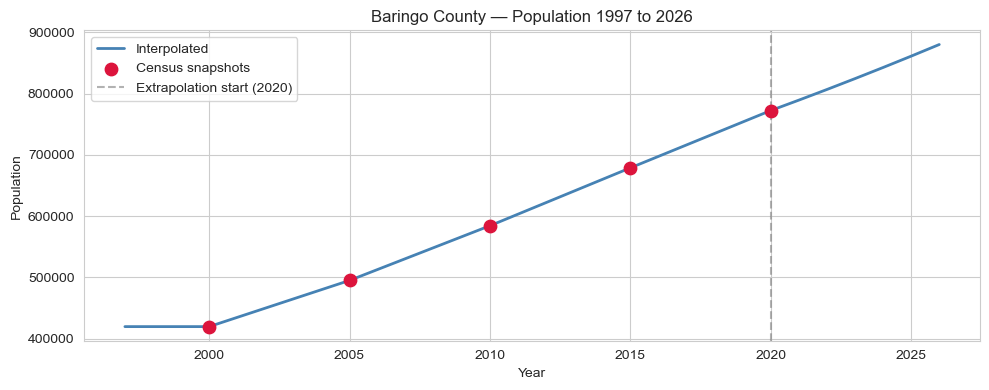

In [12]:
# Sanity check — plot Baringo population to confirm smooth interpolation
baringo = pwd_filled[pwd_filled['Adm_N'] == 'Baringo'].sort_values('year')
census_years = [2000, 2005, 2010, 2015, 2020]
baringo_census = baringo[baringo['year'].isin(census_years)]

plt.figure(figsize=(10, 4))
plt.plot(baringo['year'], baringo['Pop'], color='steelblue', linewidth=2, label='Interpolated')
plt.scatter(baringo_census['year'], baringo_census['Pop'],
            color='crimson', zorder=5, s=80, label='Census snapshots')
plt.axvline(2020, color='gray', linestyle='--', alpha=0.6, label='Extrapolation start (2020)')
plt.title('Baringo County — Population 1997 to 2026')
plt.xlabel('Year')
plt.ylabel('Population')
plt.legend()
plt.tight_layout()
plt.show()


**Note:**  
Red dots = known census values. Blue line = interpolated/extrapolated smoothly between them. The dashed line marks where 2.2% annual extrapolation begins.


### 2.7 Merge Population Features onto ACLED

Attaching the 5 population features to each ACLED row using a **left merge** on county name and year.

A left merge because:
- Every ACLED row is kept, regardless of whether a matching population row exists
- Population values are attached where county + year matches
- Counties that had no conflict events in a given year simply do not appear in ACLED and do not need a row in the merged dataset


In [13]:
# Prepare the reference table for merging
pwd_merge = pwd_filled[['Adm_N', 'year'] + PWD_VALUE_COLS].copy()
pwd_merge = pwd_merge.rename(columns={'Adm_N': 'ADMIN1', 'year': 'YEAR'})

# Rename columns to make them clearly identifiable in the merged dataset
pwd_merge = pwd_merge.rename(columns={
    'Pop':     'PWD_POPULATION',
    'Density': 'PWD_DENSITY',
    'Area':    'PWD_AREA_KM2',
    'PWD_G':   'PWD_G',
    'PWD_D10': 'PWD_D10'
})

print('Population reference table ready for merge:')
print(f'  Shape: {pwd_merge.shape}')
print(f'  Columns: {pwd_merge.columns.tolist()}')


Population reference table ready for merge:
  Shape: (1410, 7)
  Columns: ['ADMIN1', 'YEAR', 'PWD_POPULATION', 'PWD_DENSITY', 'PWD_AREA_KM2', 'PWD_G', 'PWD_D10']


In [14]:
# Perform the merge
rows_before = len(acled)
df = acled.merge(pwd_merge, on=['ADMIN1', 'YEAR'], how='left')
rows_after  = len(df)

print(f'Rows before merge: {rows_before:,}')
print(f'Rows after merge:  {rows_after:,}')
print(f'Row count preserved: {rows_before == rows_after}')
print()

# Check for any rows that did not get a population value
unmatched = df['PWD_POPULATION'].isna().sum()
print(f'Rows without population after merge: {unmatched}')


Rows before merge: 16,627
Rows after merge:  16,627
Row count preserved: True

Rows without population after merge: 0


### 2.8 Final Working Dataset Overview


In [15]:
# Final shape and column audit
print('=== FINAL MERGED DATASET ===')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns:')
for col in df.columns:
    null_count = df[col].isna().sum()
    null_pct   = null_count / len(df) * 100
    print(f'  {col:<30} dtype={str(df[col].dtype):<12} nulls={null_count} ({null_pct:.1f}%)')


=== FINAL MERGED DATASET ===
Shape: 16,627 rows x 19 columns

Columns:
  WEEK                           dtype=datetime64[ns] nulls=0 (0.0%)
  REGION                         dtype=object       nulls=0 (0.0%)
  COUNTRY                        dtype=object       nulls=0 (0.0%)
  ADMIN1                         dtype=object       nulls=0 (0.0%)
  EVENT_TYPE                     dtype=object       nulls=0 (0.0%)
  SUB_EVENT_TYPE                 dtype=object       nulls=0 (0.0%)
  EVENTS                         dtype=int64        nulls=0 (0.0%)
  FATALITIES                     dtype=int64        nulls=0 (0.0%)
  POPULATION_EXPOSURE            dtype=float64      nulls=4897 (29.5%)
  DISORDER_TYPE                  dtype=object       nulls=0 (0.0%)
  ID                             dtype=int64        nulls=0 (0.0%)
  CENTROID_LATITUDE              dtype=float64      nulls=0 (0.0%)
  CENTROID_LONGITUDE             dtype=float64      nulls=0 (0.0%)
  YEAR                           dtype=int32        

In [16]:
# Preview
df.head()

,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.40,4938.30
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185,2004,479975.8,44.8,10718.1,90.52,8113.42
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,2005,495049.0,46.2,10718.1,95.30,8907.20


In [17]:
# Save the merged dataset
OUTPUT_FILE = 'kenya_conflict_merged.csv'
df.to_csv(OUTPUT_FILE, index=False)
print(f'Dataset saved to {OUTPUT_FILE}')
print(f'Shape: {df.shape}')


Dataset saved to kenya_conflict_merged.csv
Shape: (16627, 19)


### Summary of Dataset Creation Decisions

Primarily, the WorldPop population dataset was loaded, selecting only necessary columns so as to prevent unnecessary cleaning, interpolated for intermediary values absent betwee the five year periods in which the data was provided, and the county names cleaned for similarity across both datasets. The datsets were then merged using a left join on the basis of year and county, such that only the acled rows with weekly information were kept. The decisions made along the way are tabulated below, as well as their rationale.

| Decision | Rationale |
|---|---|
| Pre-filtered ACLED to Kenya in Excel | File size only — no analytical impact |
| Selected 5 PWD columns from 25 available | Pop, Density, Area, PWD_G, PWD_D10 — theoretically motivated, non-redundant |
| Standardised 2 county names | Elgeyo-Marakwet and Murang'a spelling differences between sources |
| Linear interpolation between census years | Population grows continuously, not in 5-year steps |
| Backfill pre-2000 with 2000 value | No earlier data available; earliest known value is best available prior |
| 2.2% growth rate for post-2020 | KNBS 2019 Census inter-censal rate 2009–2019 (Figure 2.2) |
| Left merge on county + year | Preserves all ACLED rows; attaches population only where events exist |


---
## 3. Data Understanding
---


### 3.1 Dataset Preview
Taking a look at the now identified working dataset;

In [18]:
df.head()


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
0,1998-01-24,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.40,4938.30
1,1999-01-16,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
2,1999-09-25,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.40,4938.30
3,2004-08-07,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,1,NaN,Political violence,1535,0.7197,36.0185,2004,479975.8,44.8,10718.1,90.52,8113.42
4,2005-04-02,Eastern Africa,Kenya,Baringo,Battles,Armed clash,1,0,NaN,Political violence,1535,0.7197,36.0185,2005,495049.0,46.2,10718.1,95.30,8907.20


In [19]:
# Shape
print(f'Dataset contains {df.shape[0]:,} rows and {df.shape[1]} columns.')


Dataset contains 16,627 rows and 19 columns.


**Note:**  
The dataset contains 16,627 rows and columns spanning conflict event details, temporal markers, and population features derived from the WorldPop PWD merge above.


In [20]:
# Data types and null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16627 entries, 0 to 16626
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   WEEK                 16627 non-null  datetime64[ns]
 1   REGION               16627 non-null  object        
 2   COUNTRY              16627 non-null  object        
 3   ADMIN1               16627 non-null  object        
 4   EVENT_TYPE           16627 non-null  object        
 5   SUB_EVENT_TYPE       16627 non-null  object        
 6   EVENTS               16627 non-null  int64         
 7   FATALITIES           16627 non-null  int64         
 8   POPULATION_EXPOSURE  11730 non-null  float64       
 9   DISORDER_TYPE        16627 non-null  object        
 10  ID                   16627 non-null  int64         
 11  CENTROID_LATITUDE    16627 non-null  float64       
 12  CENTROID_LONGITUDE   16627 non-null  float64       
 13  YEAR                 16627 non-

**Note:**  
`POPULATION_EXPOSURE` is the only column with missing values (~29.4%). All other columns are fully populated.
This confirms the dataset is structurally clean and ready for data preparation.


In [21]:
# Statistical summary
df.describe(include='all')


,WEEK,REGION,COUNTRY,ADMIN1,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,DISORDER_TYPE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
count,16627,16627,16627,16627,16627,16627,16627.000000,16627.000000,1.173000e+04,16627,16627.000000,16627.000000,16627.000000,16627.000000,1.662700e+04,16627.000000,16627.000000,16627.000000,1.662700e+04
unique,NaN,1,1,47,6,24,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Eastern Africa,Kenya,Nairobi,Protests,Peaceful protest,NaN,NaN,NaN,Political violence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,16627,16627,1932,5474,4734,NaN,NaN,NaN,8000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2019-10-10 23:34:06.286161152,NaN,NaN,NaN,NaN,NaN,1.294882,0.949600,3.774653e+04,NaN,1557.682444,-0.360952,36.905008,2019.288567,1.551337e+06,1130.021052,12907.134916,3512.448162,8.692382e+04
min,1997-01-11 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.000000e+00,NaN,1535.000000,-4.119800,34.205100,1997.000000,8.530900e+04,3.700000,260.900000,17.300000,1.665200e+03
25%,2017-01-14 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,5.358750e+03,NaN,1547.000000,-1.301900,35.306000,2017.000000,8.065620e+05,65.224438,2349.863681,244.480000,1.332418e+04
50%,2022-10-22 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,1.582100e+04,NaN,1559.000000,-0.467500,36.827000,2022.000000,1.241895e+06,274.260000,3589.100000,615.880000,2.252690e+04
75%,2024-10-12 00:00:00,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,3.932300e+04,NaN,1565.000000,0.497900,37.777500,2024.000000,1.820566e+06,653.831618,14110.443056,1058.977284,4.199972e+04
max,2026-06-20 00:00:00,NaN,NaN,NaN,NaN,NaN,21.000000,281.000000,1.475399e+06,NaN,1581.000000,3.220100,40.711200,2026.000000,5.349955e+06,7518.607822,81254.702191,28521.210865,1.743386e+06


**Note:**  
`FATALITIES` is dominated by zeros (median = 0, mean < 1) with a small number of extreme events pulling the max to 281 — a classic rare-event, long-tail problem.
Most modelling difficulty in this project will come from this distribution, not from messy data.
Categorically, the data skews toward non-lethal unrest: 'Protests' and 'Peaceful protest' are the most common event types.


### 3.2 Duplicate Check


In [22]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')


Number of duplicate rows: 0


**Note:**  
0 duplicate rows found. No action required.


### 3.3 Skewness of Key Numeric Columns


In [23]:
numeric_skew_cols = ['EVENTS', 'FATALITIES', 'PWD_POPULATION', 'PWD_DENSITY']
df[numeric_skew_cols].skew()


EVENTS             6.114555
FATALITIES        26.131026
PWD_POPULATION     1.699592
PWD_DENSITY        2.097458
dtype: float64

**Note:**
- `FATALITIES` (skew ~26) → extremely skewed. Almost all values are 0, with a few extreme outliers up to 281. Confirms the zero-inflation problem.
- `EVENTS` (skew ~6) → also right-skewed but less extreme. Most county-weeks have just 1 event.
- `PWD_POPULATION` and `PWD_DENSITY` → moderately skewed, driven by outlier counties like Nairobi. These will be log-transformed in data preparation.


### 3.4 Correlation Between Numeric Features


In [24]:
df.corr(numeric_only=True)


,EVENTS,FATALITIES,POPULATION_EXPOSURE,ID,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,PWD_POPULATION,PWD_DENSITY,PWD_AREA_KM2,PWD_G,PWD_D10
EVENTS,1.000000,0.200076,0.422786,0.032327,-0.036531,-0.043209,0.027041,0.206028,0.195513,-0.063745,0.205163,0.046013
FATALITIES,0.200076,1.000000,0.123113,0.043812,0.098998,0.060109,-0.182143,-0.058070,-0.040378,0.127712,-0.030950,0.016928
POPULATION_EXPOSURE,0.422786,0.123113,1.000000,0.077284,-0.085880,0.113744,-0.051278,0.494683,0.499000,-0.063314,0.517064,0.117463
ID,0.032327,0.043812,0.077284,1.000000,0.137762,-0.057577,-0.085199,0.125868,0.177133,0.147358,0.183665,0.034276
CENTROID_LATITUDE,-0.036531,0.098998,-0.085880,0.137762,1.000000,-0.207489,-0.027197,-0.152940,-0.376241,0.497238,-0.308346,-0.277144
CENTROID_LONGITUDE,-0.043209,0.060109,0.113744,-0.057577,-0.207489,1.000000,-0.059174,-0.037488,0.028695,0.315190,0.031080,0.310992
YEAR,0.027041,-0.182143,-0.051278,-0.085199,-0.027197,-0.059174,1.000000,0.130207,-0.005700,-0.072034,-0.017829,0.027808
PWD_POPULATION,0.206028,-0.058070,0.494683,0.125868,-0.152940,-0.037488,0.130207,1.000000,0.819646,-0.258228,0.868458,0.150798
PWD_DENSITY,0.195513,-0.040378,0.499000,0.177133,-0.376241,0.028695,-0.005700,0.819646,1.000000,-0.341344,0.976598,0.286565
PWD_AREA_KM2,-0.063745,0.127712,-0.063314,0.147358,0.497238,0.315190,-0.072034,-0.258228,-0.341344,1.000000,-0.288755,-0.151885


**Note:**
Population, density, and most numeric features show only weak linear correlation with fatalities — the real predictive signal is likely non-linear and will need tree-based models to uncover.


### 3.5 Categorical vs Numerical Columns


In [25]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical columns:', categorical_cols)
print('\nNumerical columns:', numerical_cols)
print(f'\nTotal categorical: {len(categorical_cols)}')
print(f'Total numerical: {len(numerical_cols)}')


Categorical columns: ['REGION', 'COUNTRY', 'ADMIN1', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'DISORDER_TYPE']

Numerical columns: ['EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'ID', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE', 'PWD_POPULATION', 'PWD_DENSITY', 'PWD_AREA_KM2', 'PWD_G', 'PWD_D10']

Total categorical: 6
Total numerical: 11


### 3.6 Summary of Data Understanding Section

The dataset is structurally sound with a single column requiring attention.  
What stands out most is not a data quality issue but a distributional one: FATALITIES is so heavily dominated by zero values that standard regression assumptions break down immediately. The mean fatality count across all county-weeks is below one, yet individual events reach as high as 281 - a spread that tells us the real challenge in this project is not cleaning the data but building models robust enough to detect the rare, severe events that matter most.  
The categorical breakdown reinforces this: the majority of recorded activity is non-violent protest, meaning the model must learn to separate a large background of routine unrest from a small foreground of genuinely dangerous escalation.

---
## 4. Data Cleaning
---
To ensure the dataset is analytically sound before modelling, each column is examined individually - checking data types, redundancy, missing values, and distributions - to surface any inconsistencies that broader summary statistics might overlook.


### 4.1 Dropping Redundant Columns
Some columns present no meaning to us such as country, as they are already filtered to this specific use case.

In [26]:
# Check for constant (zero-variance) columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print('Constant columns:', constant_cols)


Constant columns: ['REGION', 'COUNTRY']


In [27]:
# Drop constant columns — they carry no information for modelling
df = df.drop(columns=['REGION', 'COUNTRY'])


In [28]:
# Drop ID and Column as it is not meaningful predictors
df = df.drop(columns=['ID'])
print(f'Shape after dropping constant columns: {df.shape}')

Shape after dropping constant columns: (16627, 16)


**Note:**  
`REGION` (constant: 'Eastern Africa') and `COUNTRY` (constant: 'Kenya') dropped. These columns carry zero variance and therefore zero predictive value.  
`ID` is also dropped as it offers no predictive information.


### 4.2 Investigating DISORDER_TYPE vs EVENT_TYPE Columns
Checking if each column offers different or meaningful information

In [29]:
# Check whether DISORDER_TYPE adds information beyond EVENT_TYPE
df.groupby('DISORDER_TYPE')['EVENT_TYPE'].unique()


DISORDER_TYPE
Demonstrations                                                        [Protests, Riots]
Political violence                    [Battles, Explosions/Remote violence, Riots, V...
Political violence; Demonstrations                                           [Protests]
Strategic developments                                         [Strategic developments]
Name: EVENT_TYPE, dtype: object

**Note:**  
`DISORDER_TYPE` is a higher-level grouping of `EVENT_TYPE` and does not add independent information.  
Notably, *Riots* appears under both *Demonstrations* and *Political violence* — meaning the grouping is not even a clean one-to-one mapping.  
`DISORDER_TYPE` is therefore both redundant and slightly inconsistent. We drop it and rely on the more granular `EVENT_TYPE` and `SUB_EVENT_TYPE`.


In [30]:
df = df.drop(columns=['DISORDER_TYPE'])
print(f'Shape after dropping DISORDER_TYPE: {df.shape}')

Shape after dropping DISORDER_TYPE: (16627, 15)


### 4.3 POPULATION_EXPOSURE Column Missing Value Treatment

`POPULATION_EXPOSURE` is ACLED's estimate of the number of people directly in the vicinity of a specific conflict event. It is an **event-level** figure, not a county-level one — it varies from event to event within the same county.

As this is fundamentally different from `PWD_POPULATION`, which is the total county population, imputing missing exposure values using county population would replace a fine-grained event-level figure with a county-wide total which would be conceptually wrong and likely to introduce noise rather than signal.

**Approach:** First create a binary `POPULATION_EXPOSURE_MISSING` flag to preserve the missingness signal (the analysis below shows missingness is systematic, not random), then fill the missing values with 0. Filling is required because scikit-learn's Random Forest does not handle NaN natively; the flag ensures no information is lost in the fill.


In [31]:
# Check whether missingness is linked to specific event types
exposure_by_type = df.groupby('EVENT_TYPE')['POPULATION_EXPOSURE'].apply(
    lambda x: f"{x.notna().sum()} / {len(x)} ({x.notna().mean()*100:.0f}% present)"
)
print('POPULATION_EXPOSURE availability by event type:')
print(exposure_by_type.to_string())


POPULATION_EXPOSURE availability by event type:
EVENT_TYPE
Battles                       1029 / 1802 (57% present)
Explosions/Remote violence      222 / 358 (62% present)
Protests                      4669 / 5474 (85% present)
Riots                         4046 / 4764 (85% present)
Strategic developments            0 / 1411 (0% present)
Violence against civilians    1764 / 2818 (63% present)


**Note:**  
Missingness in POPULATION_EXPOSURE is not random — it is systematically associated with event type. This confirms that a binary flag column will carry real signal rather than just noise.


In [32]:
# Preserve the missingness signal BEFORE filling — Cell above showed it is
# systematically tied to event type, so the flag carries real information
df['POPULATION_EXPOSURE_MISSING'] = df['POPULATION_EXPOSURE'].isna().astype(int)
print(f"Rows flagged as missing exposure: {df['POPULATION_EXPOSURE_MISSING'].sum()} "
      f"({df['POPULATION_EXPOSURE_MISSING'].mean()*100:.1f}%)")

# Now fill missing values with 0
df['POPULATION_EXPOSURE'] = df['POPULATION_EXPOSURE'].fillna(0)
# Recheck new missing values
df['POPULATION_EXPOSURE'].isna().sum()

Rows flagged as missing exposure: 4897 (29.5%)


0

### 4.4 Column Standardization
Cleaning up and standardizing the column titles for ease of use.

In [33]:
# Standardising all column names: uppercase, underscores for spaces
df = df.rename(columns={
    'ADMIN1':               'COUNTY',
    'PWD_POPULATION':       'COUNTY_POPULATION',
    'PWD_DENSITY':          'COUNTY_RAW_DENSITY',
    'PWD_AREA_KM2':         'COUNTY_AREA_KM2',
    'PWD_G':                'COUNTY_WEIGHTED_DENSITY',
    'PWD_D10':              'COUNTY_URBAN_CORE_DENSITY',
})

print('Renamed columns:')
print(df.columns.tolist())

Renamed columns:
['WEEK', 'COUNTY', 'EVENT_TYPE', 'SUB_EVENT_TYPE', 'EVENTS', 'FATALITIES', 'POPULATION_EXPOSURE', 'CENTROID_LATITUDE', 'CENTROID_LONGITUDE', 'YEAR', 'COUNTY_POPULATION', 'COUNTY_RAW_DENSITY', 'COUNTY_AREA_KM2', 'COUNTY_WEIGHTED_DENSITY', 'COUNTY_URBAN_CORE_DENSITY', 'POPULATION_EXPOSURE_MISSING']


In [34]:
# Checking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16627 entries, 0 to 16626
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   WEEK                         16627 non-null  datetime64[ns]
 1   COUNTY                       16627 non-null  object        
 2   EVENT_TYPE                   16627 non-null  object        
 3   SUB_EVENT_TYPE               16627 non-null  object        
 4   EVENTS                       16627 non-null  int64         
 5   FATALITIES                   16627 non-null  int64         
 6   POPULATION_EXPOSURE          16627 non-null  float64       
 7   CENTROID_LATITUDE            16627 non-null  float64       
 8   CENTROID_LONGITUDE           16627 non-null  float64       
 9   YEAR                         16627 non-null  int32         
 10  COUNTY_POPULATION            16627 non-null  float64       
 11  COUNTY_RAW_DENSITY           16627 non-nu

In [35]:
# Fix data types
# POPULATION_EXPOSURE — event-level exposure count, must be whole people
# Use Int64 (nullable integer) for dtype consistency
# (missing values were flagged and zero-filled in Section 4.3)
df['POPULATION_EXPOSURE'] = df['POPULATION_EXPOSURE'].astype('Int64')

# Converting Int32 to Int64
df['YEAR']    = df['YEAR'].astype('Int64')
print('Datatype changed for YEAR and POPULATION_EXPOSURE Columns')

Datatype changed for YEAR and POPULATION_EXPOSURE Columns


### 4.5 Feature Engineering

Deriving additional features from existing columns to enrich the model's signal.  



In [36]:
# Calendar features
df["MONTH"] = df["WEEK"].dt.month
df["QUARTER"] = df["WEEK"].dt.quarter
df["WEEK_OF_YEAR"] = df["WEEK"].dt.isocalendar().week.astype(int)

# Election-year feature
election_years = [2002, 2007, 2013, 2017, 2022]
df["IS_ELECTION_YEAR"] = df["YEAR"].isin(election_years).astype(int)

# Log transforms
df["LOG_POPULATION_EXPOSURE"] = np.log1p(df["POPULATION_EXPOSURE"])
df["LOG_PWD_POPULATION"] = np.log1p(df["COUNTY_POPULATION"])
df["LOG_PWD_DENSITY"] = np.log1p(df["COUNTY_RAW_DENSITY"])
df["LOG_PWD_AREA_KM2"] = np.log1p(df["COUNTY_AREA_KM2"])
df["LOG_PWD_G"] = np.log1p(df["COUNTY_WEIGHTED_DENSITY"])
df["LOG_PWD_D10"] = np.log1p(df["COUNTY_URBAN_CORE_DENSITY"])

# Sort before lag features
df = df.sort_values(["COUNTY", "WEEK"]).reset_index(drop=True)

# --- Lag and rolling features, computed on a COMPLETE weekly county panel ---
# Rows in df are county x week x event-type, and quiet weeks are absent, so a
# row-wise shift(1) would NOT be a one-week lag (it could be the same week's
# other event type, or an event from years earlier). We therefore:
#   1. aggregate to true county-week totals,
#   2. reindex every county onto the full weekly calendar (quiet weeks = 0),
#   3. compute shift/rolling on that calendar so "1W" and "4W" mean weeks,
#   4. merge the lagged features back onto the event-level rows.
weekly = (
    df.groupby(["COUNTY", "WEEK"])[["EVENTS", "FATALITIES"]]
      .sum()
      .reset_index()
)

all_weeks = pd.date_range(df["WEEK"].min(), df["WEEK"].max(), freq="W-SAT")
panel_index = pd.MultiIndex.from_product(
    [sorted(df["COUNTY"].unique()), all_weeks], names=["COUNTY", "WEEK"]
)
panel = (
    weekly.set_index(["COUNTY", "WEEK"])
          .reindex(panel_index, fill_value=0)
          .reset_index()
          .sort_values(["COUNTY", "WEEK"])
)

panel["EVENTS_LAG_1W"] = panel.groupby("COUNTY")["EVENTS"].shift(1).fillna(0)
panel["FATALITIES_LAG_1W"] = panel.groupby("COUNTY")["FATALITIES"].shift(1).fillna(0)

panel["EVENTS_ROLLING_4W"] = (
    panel.groupby("COUNTY")["EVENTS"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).sum())
    .fillna(0)
)
panel["FATALITIES_ROLLING_4W"] = (
    panel.groupby("COUNTY")["FATALITIES"]
    .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).sum())
    .fillna(0)
)

lag_cols = ["EVENTS_LAG_1W", "FATALITIES_LAG_1W",
            "EVENTS_ROLLING_4W", "FATALITIES_ROLLING_4W"]
df = df.merge(panel[["COUNTY", "WEEK"] + lag_cols],
              on=["COUNTY", "WEEK"], how="left", validate="many_to_one")

print("Feature engineering completed.")

Feature engineering completed.


**Note:**  
- IS_ELECTION_YEAR flags the 6 general election years in the dataset — a theoretically motivated signal given Kenya's electoral violence history.
- Log transforms on population and density reduce right-skew before modelling, particularly important for the Linear Regression baseline.  
- Lag and rolling features are computed on a complete weekly county panel (quiet weeks filled with 0) so that `LAG_1W` genuinely means the previous calendar week and `ROLLING_4W` the previous four calendar weeks — using only information available before the week being predicted, which prevents same-week leakage.

### 4.6 Final Dataset State


In [37]:
print('   CLEANED DATASET   ')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print('Columns and null counts:')
for col in df.columns:
    null_count = df[col].isna().sum()
    null_pct   = null_count / len(df) * 100
    print(f'  {col:<30} dtype={str(df[col].dtype):<12} nulls={null_count} ({null_pct:.1f}%)')


   CLEANED DATASET   
Shape: 16,627 rows x 30 columns

Columns and null counts:
  WEEK                           dtype=datetime64[ns] nulls=0 (0.0%)
  COUNTY                         dtype=object       nulls=0 (0.0%)
  EVENT_TYPE                     dtype=object       nulls=0 (0.0%)
  SUB_EVENT_TYPE                 dtype=object       nulls=0 (0.0%)
  EVENTS                         dtype=int64        nulls=0 (0.0%)
  FATALITIES                     dtype=int64        nulls=0 (0.0%)
  POPULATION_EXPOSURE            dtype=Int64        nulls=0 (0.0%)
  CENTROID_LATITUDE              dtype=float64      nulls=0 (0.0%)
  CENTROID_LONGITUDE             dtype=float64      nulls=0 (0.0%)
  YEAR                           dtype=Int64        nulls=0 (0.0%)
  COUNTY_POPULATION              dtype=float64      nulls=0 (0.0%)
  COUNTY_RAW_DENSITY             dtype=float64      nulls=0 (0.0%)
  COUNTY_AREA_KM2                dtype=float64      nulls=0 (0.0%)
  COUNTY_WEIGHTED_DENSITY        dtype=float64 

In [38]:
# Final preview
df.head()


,WEEK,COUNTY,EVENT_TYPE,SUB_EVENT_TYPE,EVENTS,FATALITIES,POPULATION_EXPOSURE,CENTROID_LATITUDE,CENTROID_LONGITUDE,YEAR,COUNTY_POPULATION,COUNTY_RAW_DENSITY,COUNTY_AREA_KM2,COUNTY_WEIGHTED_DENSITY,COUNTY_URBAN_CORE_DENSITY,POPULATION_EXPOSURE_MISSING,MONTH,QUARTER,WEEK_OF_YEAR,IS_ELECTION_YEAR,LOG_POPULATION_EXPOSURE,LOG_PWD_POPULATION,LOG_PWD_DENSITY,LOG_PWD_AREA_KM2,LOG_PWD_G,LOG_PWD_D10,EVENTS_LAG_1W,FATALITIES_LAG_1W,EVENTS_ROLLING_4W,FATALITIES_ROLLING_4W
0,1998-01-24,Baringo,Battles,Armed clash,1,0,0,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.4,4938.3,1,1,1,4,0,0.0,12.947257,3.693867,9.279782,4.282206,8.504979,0.0,0.0,0.0,0.0
1,1998-06-27,Baringo,Protests,Peaceful protest,1,0,0,0.7197,36.0185,1998,419683.0,39.2,10718.1,71.4,4938.3,1,6,2,26,0,0.0,12.947257,3.693867,9.279782,4.282206,8.504979,0.0,0.0,0.0,0.0
2,1999-01-16,Baringo,Battles,Armed clash,1,0,0,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,1,1,1,2,0,0.0,12.947257,3.693867,9.279782,4.282206,8.504979,0.0,0.0,0.0,0.0
3,1999-09-25,Baringo,Battles,Armed clash,1,0,0,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,1,9,3,38,0,0.0,12.947257,3.693867,9.279782,4.282206,8.504979,0.0,0.0,0.0,0.0
4,1999-09-25,Baringo,Violence against civilians,Attack,1,0,0,0.7197,36.0185,1999,419683.0,39.2,10718.1,71.4,4938.3,1,9,3,38,0,0.0,12.947257,3.693867,9.279782,4.282206,8.504979,0.0,0.0,0.0,0.0


In [39]:
# Save cleaned dataset
df.to_csv('kenya_conflict_clean.csv', index=False)
print('Cleaned dataset saved to kenya_conflict_clean.csv')
print('\n')
print(f'Shape: {df.shape}')


Cleaned dataset saved to kenya_conflict_clean.csv


Shape: (16627, 30)


---
### Summary of Data Preparation Decisions
The cleaning process was deliberately conservative; only three columns were removed, all on clear grounds of redundancy or inconsistency, and no rows were dropped.  
The most consequential decision was the treatment of POPULATION_EXPOSURE: rather than imputing with a county-wide population figure, or filling in with mean/median values based on past similar events in that county which would lead to data leakage, the missing values were filled as zeros for native handling by the tree-based models. The addition of IS_ELECTION_YEAR and the rolling 4-week window features grounds the dataset in the theoretical framework motivating this project i.e. that electoral cycles and recent conflict momentum are the primary structural drivers of violence severity in Kenya. The final shape was 16,627 rows and 30 columns.

| Decision | Rationale |
|---|---|
| Dropped REGION, COUNTRY | Constant columns - zero variance, zero predictive value |
| Dropped ID | Information contained does not contribute to modelling predictability |
| Dropped DISORDER_TYPE | Redundant with EVENT_TYPE and inconsistently mapped |
| Flagged then filled POPULATION_EXPOSURE | `POPULATION_EXPOSURE_MISSING` flag created first to preserve the informative missingness signal, then filled with 0 — imputing with county population would conflate an event-level figure with a county-level one |
| Added EVENTS_ROLLING_4W | To factor in conflict escalation patterns — computed on a complete weekly county panel so the window reflects calendar weeks, not rows |
| Added FATALITIES_ROLLING_4W | To factor in conflict fatality patterns |
| Added IS_ELECTION_YEAR | Electoral cycles are theoretically the key driver of violence spikes |
| Log-transformed columns | Reduces right-skew; important for Linear Regression baseline |



---
## 5. Exploratory Data Analysis
---

This section explores the cleaned dataset through outlier detection, univariate analysis of individual distributions, and bivariate analysis of feature–target relationships - surfacing the patterns that will inform modelling decisions.

### 5.1 Outlier Detection

#### **5.1.1 Outliers in key numeric columns**

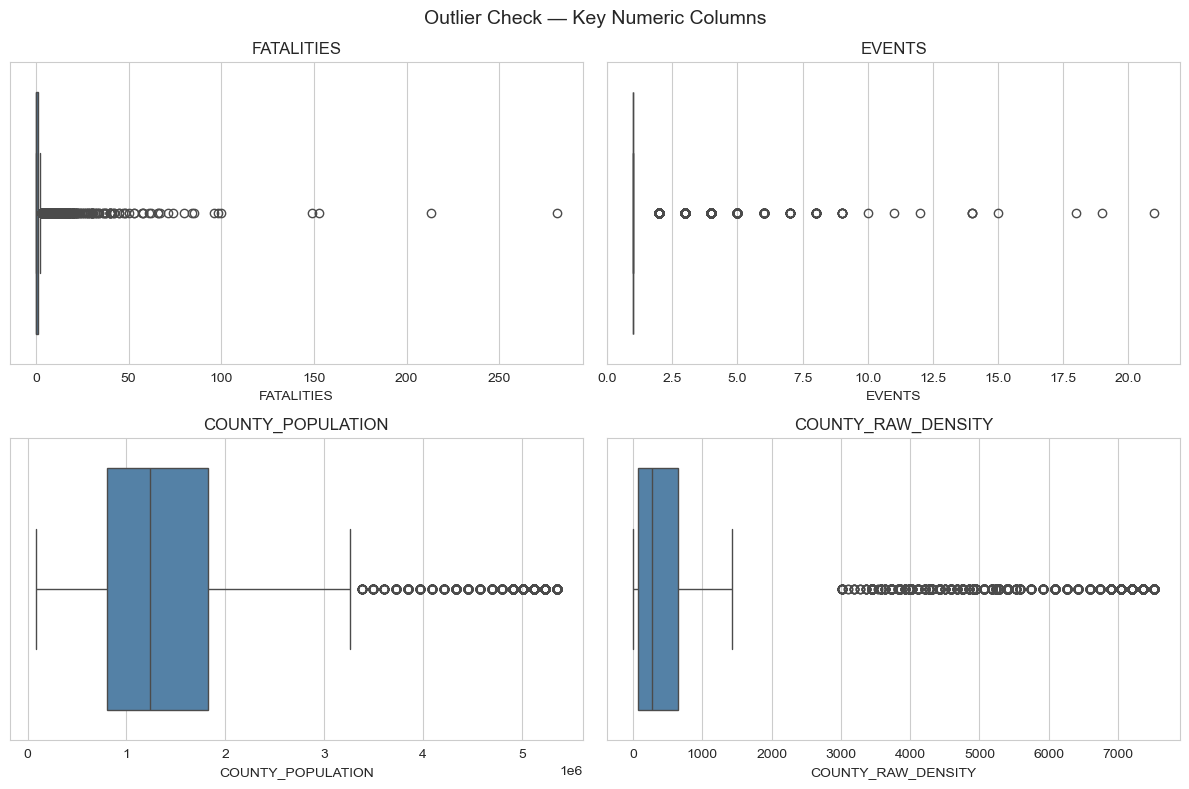

In [40]:
# Boxplots to visualise outliers in key numeric columns
outlier_cols = ['FATALITIES', 'EVENTS', 'COUNTY_POPULATION', 'COUNTY_RAW_DENSITY']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), outlier_cols):
    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontsize=12)
plt.suptitle('Outlier Check — Key Numeric Columns', fontsize=14)
plt.tight_layout()
plt.show()

**Note:**  
- All outliers are retained - in this problem they are the phenomenon of interest, not noise to be cleaned.
- FATALITIES extremes (max 281) correspond to genuine mass-violence events - the exact outcomes this project must predict; their influence is managed through robust evaluation (MAE alongside RMSE) and tree-based models.
- EVENTS outliers (15–21 events per week) represent real escalation periods - the signal captured by EVENTS_ROLLING_4W.
- COUNTY_POPULATION and COUNTY_RAW_DENSITY outliers are structurally dense urban counties (Nairobi, Mombasa) appearing repeatedly across weeks - already addressed via the log transforms in Section 4.5.

#### **5.1.2 outliers per column using the IQR rule**

In [41]:
# Count outliers per column using the IQR rule (1.5 x IQR beyond Q1/Q3)
outlier_summary = []
for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        'Column': col,
        'Q1': q1, 'Q3': q3,
        'Upper Bound': upper,
        'Max Value': df[col].max(),
        'Outliers': n_outliers,
        'Outlier %': round(n_outliers / len(df) * 100, 1)
    })

pd.DataFrame(outlier_summary)

,Column,Q1,Q3,Upper Bound,Max Value,Outliers,Outlier %
0,FATALITIES,0.000000,1.000000e+00,2.500000e+00,2.810000e+02,1429,8.6
1,EVENTS,1.000000,1.000000e+00,1.000000e+00,2.100000e+01,3050,18.3
2,COUNTY_POPULATION,806562.034124,1.820566e+06,3.341571e+06,5.349955e+06,1550,9.3
3,COUNTY_RAW_DENSITY,65.224438,6.538316e+02,1.536742e+03,7.518608e+03,2546,15.3


**Note:**  
- FATALITIES: 1,429 rows (8.6%) are flagged because most weeks have 0 or 1 fatalities, so anything above 2.5 counts as an outlier - these are real violent events, not errors.
- EVENTS: most weeks have exactly 1 event, so the rule flags every week with 2 or more (18.3%) - far too many to truly be outliers, showing the IQR rule struggles with count data like this.
- COUNTY_POPULATION and COUNTY_RAW_DENSITY: the flagged rows are just the big urban counties (like Nairobi) appearing week after week - real places, not bad data.
- Overall, the high percentages simply confirm the data is heavily skewed - the treatment decision is to keep them all

#### **5.1.3 Maximum Fatality Recorded in a year**

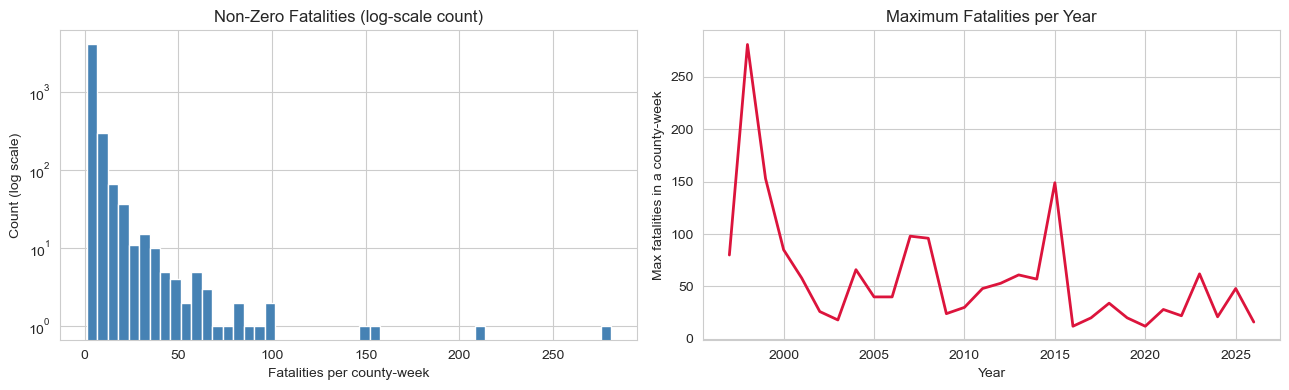

In [42]:
# Distribution of the non-zero fatality tail
nonzero = df[df['FATALITIES'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(nonzero['FATALITIES'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Non-Zero Fatalities (log-scale count)')
axes[0].set_xlabel('Fatalities per county-week')
axes[0].set_ylabel('Count (log scale)')

nonzero.groupby(nonzero['WEEK'].dt.year)['FATALITIES'].max().plot(
    ax=axes[1], color='crimson', linewidth=2)
axes[1].set_title('Maximum Fatalities per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Max fatalities in a county-week')

plt.tight_layout()
plt.show()

**Note:**  
- Even among non-zero weeks, most have fewer than 10 fatalities - the counts drop off sharply, with only a handful of extreme weeks above 100.
- The yearly maximums line up with known events in Kenya's history: the largest spike (281) occurs in 1998 during the post-1997-election ethnic clashes, the 2007/08 post-election crisis is clearly visible, and the ~150 spike in 2015 matches the Garissa University attack.
- This confirms the extreme values are genuine historical events, not data errors.

**Outlier Treatment Decision:**  
- All outliers are kept - no removal, no capping.
- The extreme fatality weeks are exactly what this model exists to predict; deleting them would remove the very signal we want to learn.
- Their influence is managed instead by using MAE (a metric not distorted by extremes) alongside RMSE, and by tree-based models, which handle extreme values much better than linear regression.

### 5.2 Univariate Analysis

Examining the distribution of individual variables - the target, key categorical columns, and temporal patterns.

#### **5.2.1 Target variable distribution**

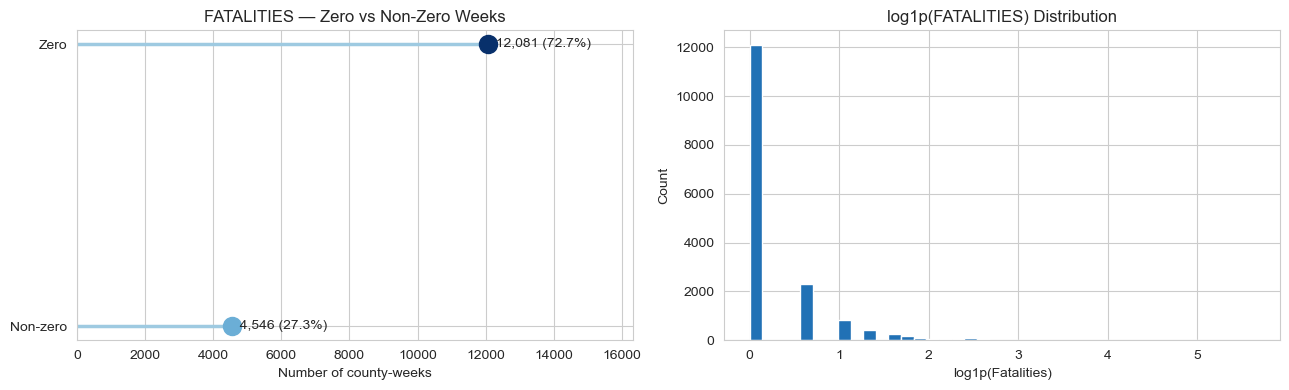

In [43]:
# Distribution of the target: FATALITIES
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: lollipop — zero vs non-zero weeks
zero_count    = (df['FATALITIES'] == 0).sum()
nonzero_count = (df['FATALITIES'] > 0).sum()

labels = ['Non-zero', 'Zero']
values = [nonzero_count, zero_count]
colors = ['#6baed6', '#08306b']

axes[0].hlines(y=labels, xmin=0, xmax=values, color='#9ecae1', linewidth=2.5)
for label, v, c in zip(labels, values, colors):
    axes[0].plot(v, label, 'o', markersize=13, color=c)
    axes[0].text(v, label, f'  {v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=10)

axes[0].set_title('FATALITIES — Zero vs Non-Zero Weeks')
axes[0].set_xlabel('Number of county-weeks')
axes[0].set_xlim(0, max(values) * 1.35)

# Right: log-transformed distribution
axes[1].hist(np.log1p(df['FATALITIES']), bins=40, color='#2171b5', edgecolor='white')
axes[1].set_title('log1p(FATALITIES) Distribution')
axes[1].set_xlabel('log1p(Fatalities)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Note:**  
- 72.7% of county-weeks (12,081) record zero fatalities, while only 27.3% (4,546) involve at least one death - confirming this is a rare-event prediction problem.
- Even after log transformation, the distribution remains dominated by the zero spike with a rapidly thinning tail - the skew comes from zero-inflation itself, which no transformation can remove.
- This shapes the modelling strategy: the models must learn both *when* violence turns deadly and *how* deadly it becomes.

#### **5.2.2 Event type Frequency**

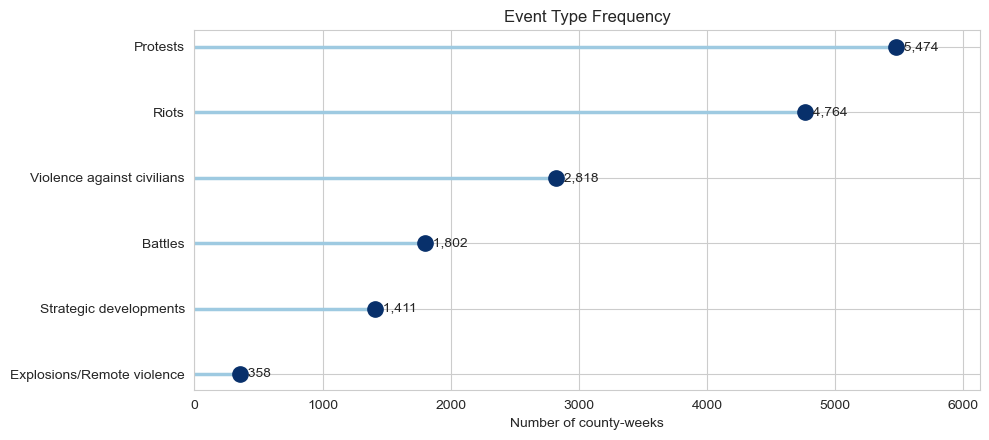

In [44]:
# Lollipop chart - event type frequency
event_counts = df['EVENT_TYPE'].value_counts().sort_values()

plt.figure(figsize=(10, 4.5))
plt.hlines(y=event_counts.index, xmin=0, xmax=event_counts.values,
           color='#9ecae1', linewidth=2.5)
plt.plot(event_counts.values, event_counts.index, 'o',
         markersize=11, color='#08306b')

for i, v in enumerate(event_counts.values):
    plt.text(v, i, f'  {v:,}', va='center', fontsize=10)

plt.title('Event Type Frequency')
plt.xlabel('Number of county-weeks')
plt.xlim(0, event_counts.max() * 1.12)
plt.tight_layout()
plt.show()

**Note:**  
- Protests (5,474) and Riots (4,764) dominate, together making up over 60% of all county-weeks - most conflict activity in Kenya is unrest, not warfare.
- Violence against civilians (2,818) and Battles (1,802) are less frequent but are the categories most likely to drive fatalities - a relationship to be confirmed in the bivariate analysis.
- Explosions/Remote violence is rare (358) but potentially high-severity per event.
- This imbalance suggests EVENT_TYPE will be a strong predictor: the *type* of event likely matters more for fatality severity than the raw *number* of events.

#### **5.2.3 Counties by total events and total fatalities**

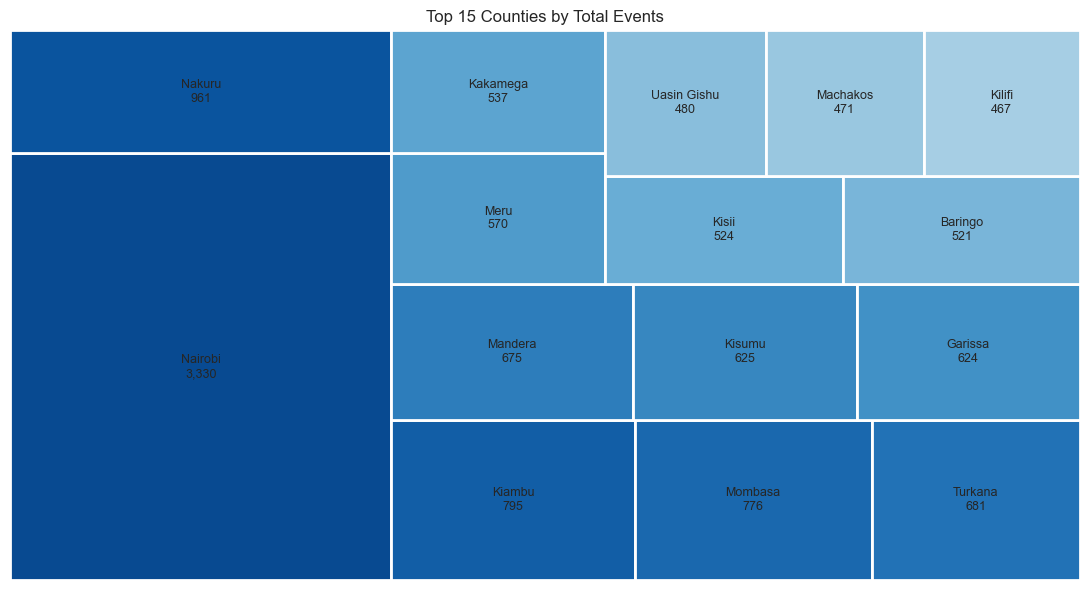

In [45]:
# Treemap - top 15 counties by total events
top_events = df.groupby('COUNTY')['EVENTS'].sum().nlargest(15)
blues = plt.cm.Blues(np.linspace(0.9, 0.35, len(top_events)))

plt.figure(figsize=(11, 6))
squarify.plot(sizes=top_events.values,
              label=[f'{c}\n{v:,}' for c, v in top_events.items()],
              color=blues, edgecolor='white', linewidth=2,
              text_kwargs={'fontsize': 9})
plt.title('Top 15 Counties by Total Events')
plt.axis('off')
plt.tight_layout()
plt.show()

**Note:**  
- Nairobi dominates conflict activity with over 3,300 events - its block is bigger than the next three counties combined.
- Its lead comes from protests and riots, which are frequent in the capital but rarely deadly.
- Activity is heavily concentrated: a handful of urban counties account for most of Kenya's conflict events.

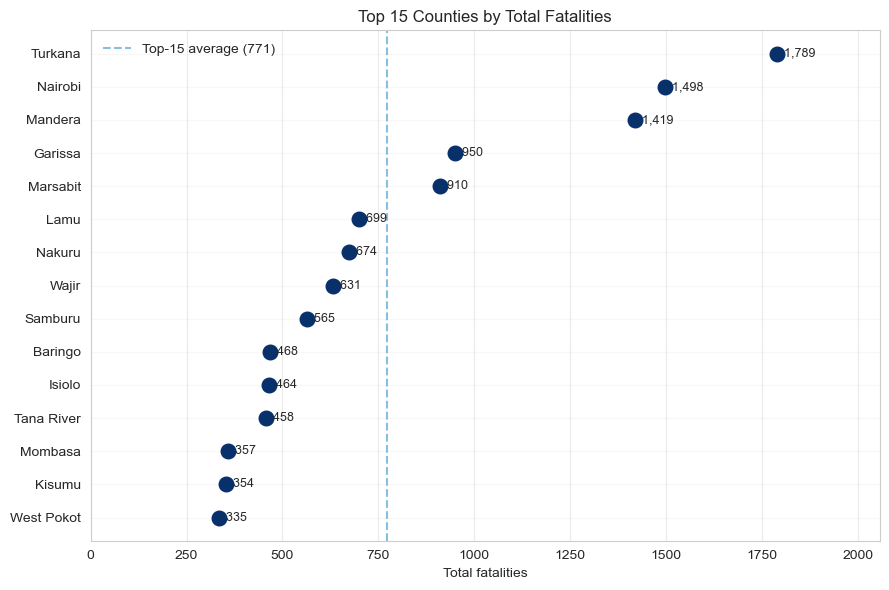

In [46]:
# Dot plot — top 15 counties by total fatalities
top_fatal = df.groupby('COUNTY')['FATALITIES'].sum().nlargest(15).sort_values()
mean_val = top_fatal.mean()

plt.figure(figsize=(9, 6))
plt.scatter(top_fatal.values, top_fatal.index, s=110, color='#08306b', zorder=3)
plt.axvline(mean_val, color='#6baed6', linestyle='--', alpha=0.8,
            label=f'Top-15 average ({mean_val:,.0f})')

for i, v in enumerate(top_fatal.values):
    plt.text(v, i, f'  {v:,}', va='center', fontsize=9)

plt.grid(axis='x', alpha=0.4)
plt.grid(axis='y', alpha=0.15)
plt.title('Top 15 Counties by Total Fatalities')
plt.xlabel('Total fatalities')
plt.xlim(0, top_fatal.max() * 1.15)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

**Note:**  
- Turkana leads in total deaths, followed by Nairobi and Mandera - only these three sit above the top-15 average (dashed line).
- The deadliest counties are mostly northern pastoral ones (Turkana, Mandera, Garissa, Marsabit, Wajir), where conflict is less frequent but far more lethal.
- This confirms COUNTY as a key predictor and matches the known hotspots named in the success criteria.

#### **5.2.4 Events/Fatalities over time**

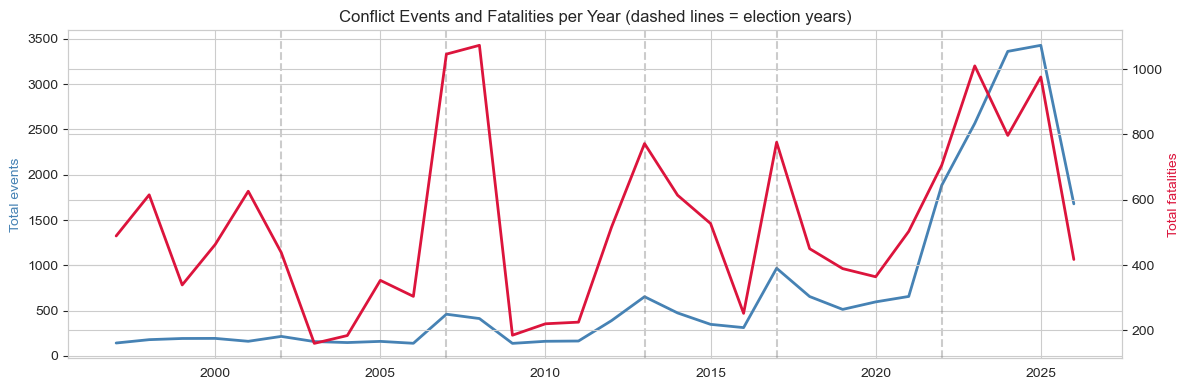

In [47]:
# Yearly totals: events and fatalities over time
yearly = df.groupby('YEAR')[['EVENTS', 'FATALITIES']].sum()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(yearly.index, yearly['EVENTS'], color='steelblue', linewidth=2, label='Events')
ax1.set_ylabel('Total events', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(yearly.index, yearly['FATALITIES'], color='crimson', linewidth=2, label='Fatalities')
ax2.set_ylabel('Total fatalities', color='crimson')

# Mark election years
for yr in [2002, 2007, 2013, 2017, 2022]:
    ax1.axvline(yr, color='gray', linestyle='--', alpha=0.4)

ax1.set_title('Conflict Events and Fatalities per Year (dashed lines = election years)')
plt.tight_layout()
plt.show()

**Note:**  
- Fatalities spike sharply around election years - 2007/08 shows the largest peak (the post-election crisis), with clear surges around 2013, 2017, and 2022/23 - strong visual evidence for the IS_ELECTION_YEAR feature.
- Events and fatalities move differently: events stayed relatively flat for two decades, then surged dramatically from 2021 onwards, peaking above 3,400 in 2024/25 - reflecting the recent wave of protests (e.g. the 2024 Finance Bill demonstrations).
- The recent period is high-events but comparatively lower fatalities per event - consistent with protest-driven unrest rather than mass-casualty violence.
- The apparent drop in 2026 is an artefact: the data only runs to June 2026, so it is a partial year, not a genuine decline.

#### **5.2.5  Severity Class Balance**

In [48]:
# Severity band — persistent column for later model diagnostics
def severity_band(x):
    if x == 0:
        return '0 None'
    if x <= 4:
        return '1 Low (1-4)'
    if x <= 19:
        return '2 Moderate (5-19)'
    return '3 Severe (20+)'

df['SEVERITY_BAND'] = df['FATALITIES'].apply(severity_band)

severity_table = (
    df['SEVERITY_BAND']
    .value_counts()
    .sort_index()
    .rename_axis('severity_band')
    .reset_index(name='weeks')
)
severity_table['share_%'] = (severity_table['weeks'] / len(df) * 100).round(1)
severity_table

,severity_band,weeks,share_%
0,0 None,12081,72.7
1,1 Low (1-4),3804,22.9
2,2 Moderate (5-19),653,3.9
3,3 Severe (20+),89,0.5


**Note:**  
- 72.7% of county-weeks (12,081) have no deaths, and 22.9% are low severity (1–4 deaths).
- Severe weeks (20+ deaths) are extremely rare - just 89 out of 16,627 weeks (0.5%).
- Those 89 weeks are the events this model exists to flag - a needle-in-a-haystack problem that shapes every modelling choice ahead.
- SEVERITY_BAND is derived directly from FATALITIES (the target), so it is kept for EDA and evaluation only - it will not be used as a model feature.

### 5.3 Bivariate Analysis

Examining how key features relate to the target (FATALITIES) - event type, election cycles, population features, and the escalation signal.

#### **5.3.1 Fatalities per county-week by event type**

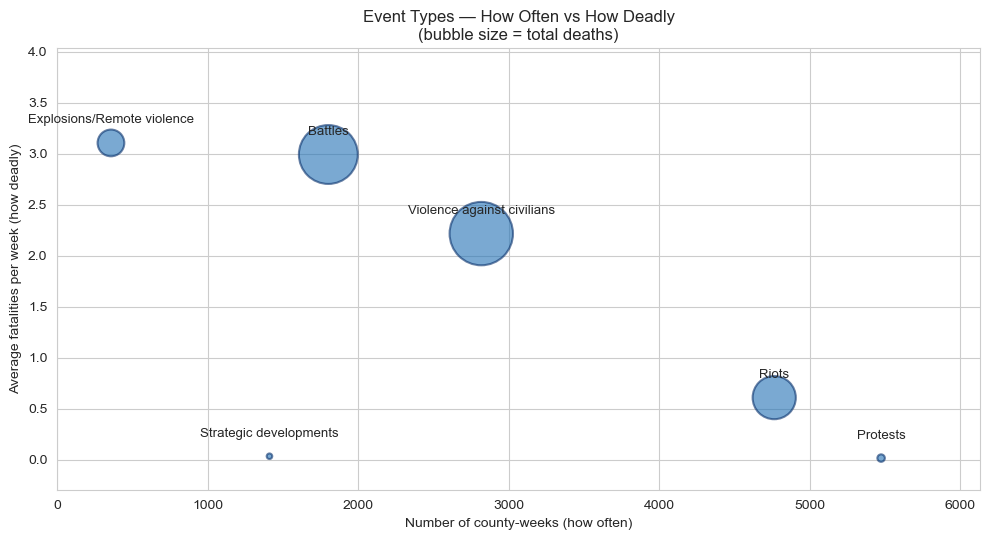

In [49]:
# Bubble chart: frequency vs deadliness, bubble size = total deaths
summary = df.groupby('EVENT_TYPE').agg(
    weeks=('EVENTS', 'size'),
    mean_fatal=('FATALITIES', 'mean'),
    total_fatal=('FATALITIES', 'sum')
)

plt.figure(figsize=(10, 5.5))
plt.scatter(summary['weeks'], summary['mean_fatal'],
            s=summary['total_fatal'] / 3, color='#2171b5',
            alpha=0.6, edgecolors='#08306b', linewidths=1.5)

for name, row in summary.iterrows():
    plt.annotate(name, (row['weeks'], row['mean_fatal']),
                 textcoords='offset points', xytext=(0, 14),
                 ha='center', fontsize=9.5)

plt.title('Event Types — How Often vs How Deadly\n(bubble size = total deaths)')
plt.xlabel('Number of county-weeks (how often)')
plt.ylabel('Average fatalities per week (how deadly)')
plt.ylim(-0.3, summary['mean_fatal'].max() * 1.3)
plt.xlim(0, summary['weeks'].max() * 1.12)
plt.tight_layout()
plt.show()

**Note:**  
- Each bubble is an event type: position shows how often it happens (x) and how deadly it is on average (y); bubble size shows total deaths.
- Protests sit bottom-right — very common, almost never deadly. Explosions and Battles sit top-left - rare but the deadliest per week.
- Violence against civilians is the largest bubble - the biggest total killer, because it is both fairly deadly and fairly frequent.
- Frequency and deadliness are almost opposites - confirming EVENT_TYPE as one of the strongest predictors of fatalities.

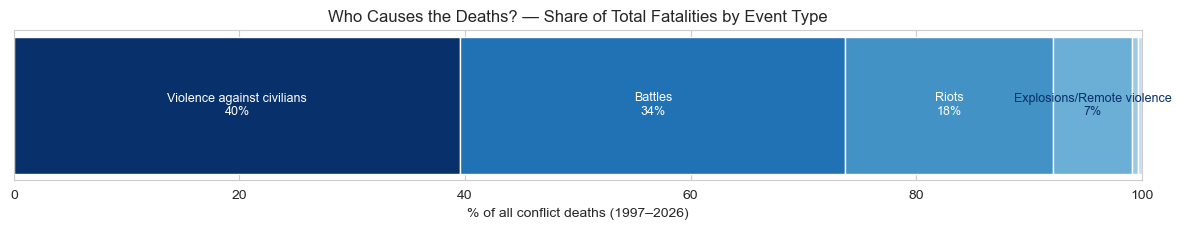

In [50]:
# Stacked ribbon - share of total deaths by event type
totals = df.groupby('EVENT_TYPE')['FATALITIES'].sum().sort_values(ascending=False)
pct = totals / totals.sum() * 100
colors = ['#08306b', '#2171b5', '#4292c6', '#6baed6', '#9ecae1', '#c6dbef']

fig, ax = plt.subplots(figsize=(12, 2.4))
left = 0
for (name, p), c in zip(pct.items(), colors):
    ax.barh(0, p, left=left, color=c, edgecolor='white')
    if p > 4:
        ax.text(left + p/2, 0, f'{name}\n{p:.0f}%', ha='center', va='center',
                fontsize=9, color='white' if p > 15 else '#08306b')
    left += p

ax.set_yticks([])
ax.set_xlim(0, 100)
ax.set_xlabel('% of all conflict deaths (1997–2026)')
ax.set_title('Who Causes the Deaths? — Share of Total Fatalities by Event Type')
plt.tight_layout()
plt.show()

**Note:**  
- Violence against civilians and Battles together account for roughly three-quarters of all conflict deaths in Kenya.
- Riots contribute a meaningful share, while Protests - the most common event type - cause almost none.
- Deaths are concentrated in a few event types, reinforcing EVENT_TYPE as a core predictor.

#### **5.3.2 Monthly Seasonality**

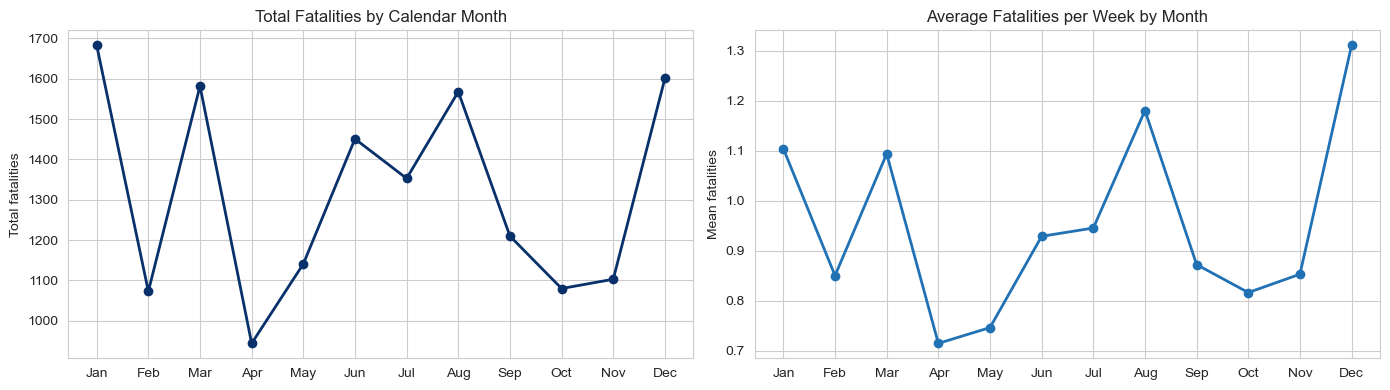

In [51]:
# Monthly seasonality - are some months of the year consistently deadlier?
df['MONTH'] = df['WEEK'].dt.month

monthly = df.groupby('MONTH').agg(
    total_fatalities=('FATALITIES', 'sum'),
    mean_fatalities=('FATALITIES', 'mean')
).reset_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(monthly['MONTH'], monthly['total_fatalities'],
             marker='o', color='#08306b', linewidth=2)
axes[0].set_title('Total Fatalities by Calendar Month')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_ylabel('Total fatalities')

axes[1].plot(monthly['MONTH'], monthly['mean_fatalities'],
             marker='o', color='#2171b5', linewidth=2)
axes[1].set_title('Average Fatalities per Week by Month')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_ylabel('Mean fatalities')

plt.tight_layout()
plt.show()

**Note:**  
- Fatalities are not spread evenly across the year - clear peaks appear in December–January, March, and August, with December–January the deadliest stretch overall.
- These peaks line up with Kenya's political calendar: elections are held in August (and December 2007), and post-election violence spills into December–January - the 2007/08 crisis being the clearest example.
- April, October, and November are consistently the calmest months.
- This seasonal pattern supports keeping MONTH as a model feature and is directly useful for early warning - resources can be pre-positioned ahead of the high-risk months.

#### **5.3.3 Election Cycles vs Violence Severity**

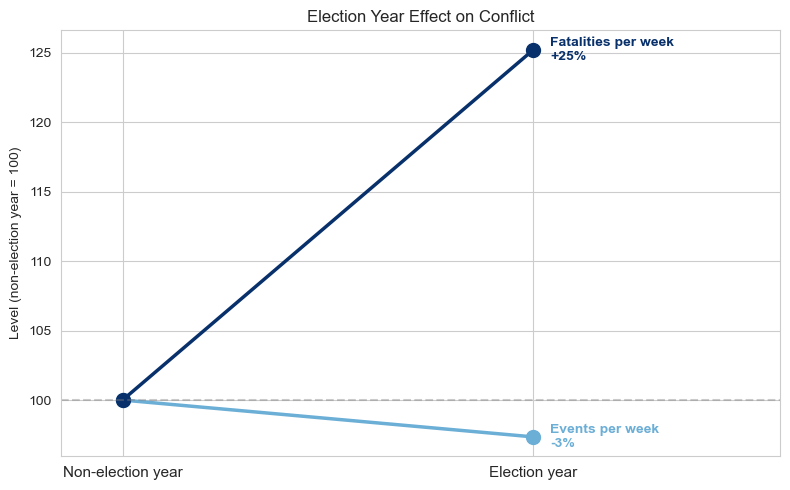

In [52]:
# Slope chart - election year effect
means = df.groupby('IS_ELECTION_YEAR')[['EVENTS', 'FATALITIES']].mean()

# Index each measure to 100 in non-election years so both fit one axis
normed = means / means.loc[0] * 100

fig, ax = plt.subplots(figsize=(8, 5))

styles = {'EVENTS': ('#6baed6', 'Events per week'),
          'FATALITIES': ('#08306b', 'Fatalities per week')}

for col, (color, label) in styles.items():
    y0, y1 = normed.loc[0, col], normed.loc[1, col]
    ax.plot([0, 1], [y0, y1], marker='o', markersize=10,
            color=color, linewidth=2.5, label=label)
    ax.text(1.04, y1, f'{label}\n{y1 - 100:+.0f}%', va='center',
            fontsize=10, color=color, fontweight='bold')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-election year', 'Election year'], fontsize=11)
ax.set_ylabel('Level (non-election year = 100)')
ax.axhline(100, color='gray', linestyle='--', alpha=0.4)
ax.set_xlim(-0.15, 1.6)
ax.set_title('Election Year Effect on Conflict')
plt.tight_layout()
plt.show()

**Note:**  
- The Events line stays flat - election years bring roughly the same amount of unrest as normal years.
- The Fatalities line climbs steeply - deaths per week are about 25% higher in election years.
- Elections don't cause more conflict; they make the conflict that happens deadlier - confirming IS_ELECTION_YEAR as a useful severity signal.

#### **5.3.4 county population/density vs fatalities**

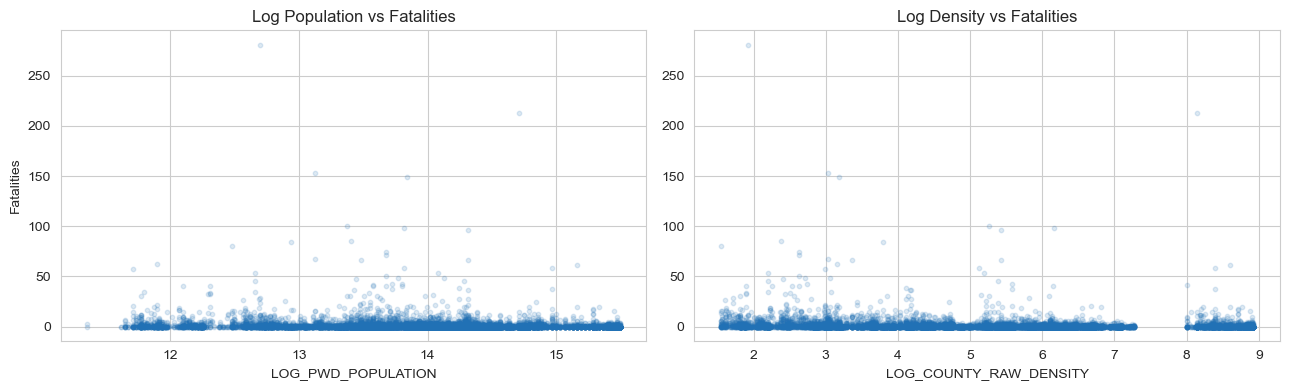

In [53]:
# Relationship between county population/density and fatalities
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(df['LOG_PWD_POPULATION'], df['FATALITIES'], alpha=0.15, color='#2171b5', s=10)
axes[0].set_title('Log Population vs Fatalities')
axes[0].set_xlabel('LOG_PWD_POPULATION')
axes[0].set_ylabel('Fatalities')

axes[1].scatter(df['LOG_PWD_DENSITY'], df['FATALITIES'], alpha=0.15, color='#2171b5', s=10)
axes[1].set_title('Log Density vs Fatalities')
axes[1].set_xlabel('LOG_COUNTY_RAW_DENSITY')

plt.tight_layout()
plt.show()

**Note:**  
- There is no clear pattern here - counties with more people or higher density are not automatically deadlier.
- In fact, the deadliest weeks (including the 281-death week) happened in *low*-density counties like Turkana and Mandera.
- The separate cluster on the far right of the density plot is Nairobi - lots of events, but mostly few deaths.
- So population and density alone can't predict deaths in a simple straight-line way - tree-based models will be needed to pick up the more complex patterns.

#### **5.3.5 Correlation heatmap of numerical features vs Target Column**

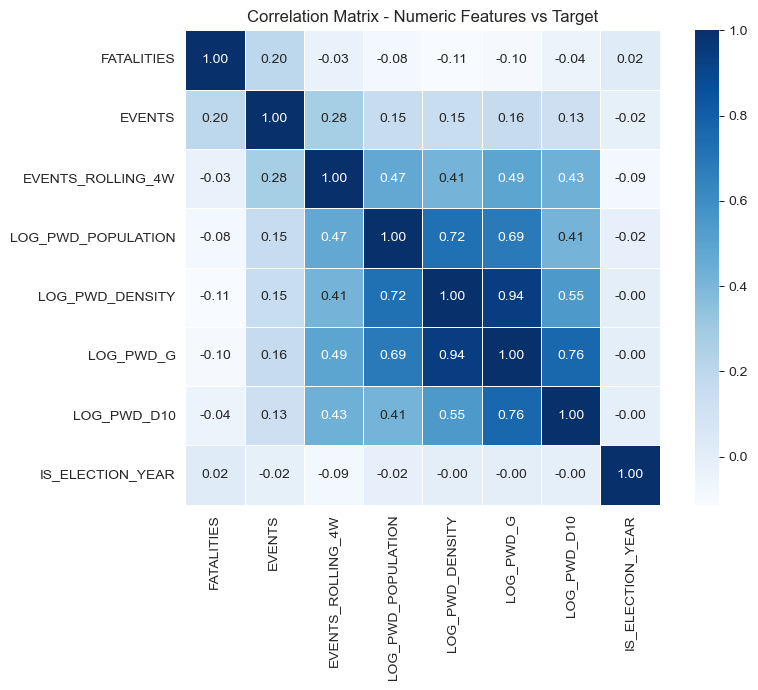

In [54]:
# Correlation heatmap of numeric features with the target
corr_cols = ['FATALITIES', 'EVENTS', 'EVENTS_ROLLING_4W', 'LOG_PWD_POPULATION',
             'LOG_PWD_DENSITY', 'LOG_PWD_G',
             'LOG_PWD_D10', 'IS_ELECTION_YEAR']

plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].astype(float).corr(), annot=True, fmt='.2f',
            cmap='Blues', square=True, linewidths=0.5)
plt.title('Correlation Matrix - Numeric Features vs Target')
plt.tight_layout()
plt.show()

**Note:**  
- No feature has a strong straight-line link with FATALITIES - the highest is EVENTS at just 0.20. This confirms the patterns are non-linear, so Linear Regression will struggle while tree-based models should do better.
- The population and density features are strongly linked to *each other* (0.62–0.72) - expected, since they all describe the same counties. Tree-based models handle this fine, but it will make Linear Regression's coefficients unreliable.
- IS_ELECTION_YEAR shows almost zero correlation (0.02) here, yet the bar chart showed election years are ~25% deadlier - a good reminder that low correlation doesn't mean a feature is useless; its effect is real but too subtle for a simple correlation to capture.
- Overall: weak linear signals everywhere support the choice of Random Forest, XGBoost, and Gradient Boosting as the main models.

### Summary of EDA

---
### Summary of Exploratory Data Analysis Findings
---

The exploratory analysis of the merged ACLED–WorldPop dataset (16,627 county-week
observations, 1997–2026) surfaced five findings that directly shape the modelling
strategy:

**1. The target is severely zero-inflated and long-tailed.**
`FATALITIES` has a skewness of ~26, with 72.6% of county-weeks recording zero
fatalities and a maximum of 281 in a single county-week. The median is 0 and the
mean is below 1. This is the defining analytical challenge of the project — the
difficulty lies in the target's distribution, not in data quality.

**2. Linear relationships with the target are weak.**
Correlation analysis showed only weak linear association between fatalities and
the numeric features, including population and density. This strongly suggests
the predictive signal is non-linear and interaction-driven, motivating the choice
of tree-based ensembles (Random Forest, XGBoost, Gradient Boosting) over a purely
linear approach — Linear Regression is retained only as a baseline.

**3. The data skews toward non-lethal unrest.**
'Protests' and 'Peaceful protest' dominate the event-type distribution, while
the high-fatality tail is concentrated in a small number of violent event types.
Event type is therefore expected to be among the strongest predictors of severity.

**4. Population features are right-skewed but usable.**
`COUNTY_POPULATION` and `COUNTY_RAW_DENSITY` are moderately skewed, driven by
outlier counties such as Nairobi. Log transforms (`LOG_COUNTY_POPULATION`,
`LOG_COUNTY_RAW_DENSITY`) were applied to stabilise these for the linear baseline;
tree-based models are unaffected by the skew.

**5. Missingness is informative, not random.**
`POPULATION_EXPOSURE` (~29.4% missing) was the only column with missing values,
and its missingness is systematically tied to event type. Rather than imputing —
which would conflate an event-level figure with county-level population — a
`POPULATION_EXPOSURE_MISSING` flag was created *before* filling the NaN values
with 0, so the informative signal in the missingness itself is retained as a
model feature.



---
## 6. Modelling
---

### 6.0 Modelling Approach

This section builds the modelling approach for the project: The modelling strategy is a **two-stage hurdle model**.

**Stage 1:**  
Predict whether violence becomes fatal.  
- `0` - Non-fatal violence
- `1` - Fatal violence

**Stage 2:**  
If violence is fatal, classify the fatality severity level.  
- **Low**: `1-2 fatalities`
- **Medium**: `3-5 fatalities`
- **High**: `6+ fatalities`

This is a statistically sound approach because it reduces extreme class imbalance while preserving the project's real-world purpose: identifying fatality severity risk.

**Prediction framing:** the feature set includes attributes of the current week's recorded events (event type, sub-event type, event count, population exposure). The system is therefore *event-conditional*: given that conflict events are occurring in a county-week, it predicts whether they turn fatal and how severe they become, a triage/nowcasting tool for unfolding situations. A pure week-ahead forecaster restricted to lagged features only is identified as future work in Section 7.2.
The final output classes are:  

| Class | Fatalities |
|---|---| 
| Non-fatal | 0 Fatalities |
| Low | 1-2 fatalities |
| Medium | 3-5 fatalities |
| High | 6+ fatalities |

This structure is selected as opposed to direct fatality regression because the data is zero-heavy, skewed, and rare-event driven.

### 6.1 Target Definition


#### **6.1.1 Stage 1 Target: Fatal vs Non-Fatal**    
`IS_FATAL` Binary column is the output target where:  
- `0` = no fatalities
- `1` = one or more fatalities


In [55]:
# TARGET DEFINITION
TARGET = "FATALITIES"

# Stage 1 target
df["IS_FATAL"] = (df["FATALITIES"] > 0).astype(int)

# Stage 2 target: only meaningful for fatal rows
def fatality_severity_3class(x):
    if x <= 2:
        return "Low"
    elif x <= 5:
        return "Medium"
    else:
        return "High"

df["FATALITY_SEVERITY"] = df["FATALITIES"].apply(fatality_severity_3class)

print("Stage 1 target distribution: IS_FATAL")
print("Counts:")
print(df["IS_FATAL"].value_counts())
print("\nShares:")
print(df["IS_FATAL"].value_counts(normalize=True)*100)



Stage 1 target distribution: IS_FATAL
Counts:
IS_FATAL
0    12081
1     4546
Name: count, dtype: int64

Shares:
IS_FATAL
0    72.658928
1    27.341072
Name: proportion, dtype: float64


#### **6.1.2 Stage 2 Target: Fatality Severity**  
Stage 2 uses only fatal rows for training, as only the rows deemed fatal from the first stage will be used for the second stage.The final classes are:  
- Low: `1-2 fatalities`
- Medium: `3-5 fatalities`
- High: `6+ fatalities`

In [56]:
print("\nStage 2 severity distribution on all rows:")
print("Counts:")
print(df["FATALITY_SEVERITY"].value_counts())

print("\nStage 2 severity distribution on fatal rows only:")
print("Shares:")
print(df.loc[df["FATALITIES"] > 0, "FATALITY_SEVERITY"].value_counts(normalize=True)*100)


Stage 2 severity distribution on all rows:
Counts:
FATALITY_SEVERITY
Low       15198
Medium      853
High        576
Name: count, dtype: int64

Stage 2 severity distribution on fatal rows only:
Shares:
FATALITY_SEVERITY
Low       68.565772
Medium    18.763748
High      12.670480
Name: proportion, dtype: float64


**Note:**  
The dataset is moderately imbalanced, with non-fatal and Low severity events dominating. This class imbalance makes minority classes (fatal, Medium, and High severity) more difficult to predict, necessitating the use of balanced evaluation metrics such as Precision, Recall, Macro F1-score, and appropriate imbalance-handling techniques during model training.

### 6.2 Feature Selection and Leakage Control

This section selects the predictor columns. Target columns are excluded to prevent leakage.

| Column | Status | Reason |
|---|---|---|
| `FATALITIES` | Excluded | Target for Stage 1 derivation only |
| `IS_FATAL` | Excluded from Stage 2 | Derived from target |
| `FATALITY_SEVERITY` | Target for Stage 2 | Excluded from features |
| `SEVERITY_BAND` | Excluded | Derived from FATALITIES |
| `EVENTS` | Included | Current-week event count — available under the event-conditional framing (Section 6.0), where prediction happens once events are being recorded |
| `WEEK` | Excluded | Captured by YEAR, MONTH, IS_ELECTION_YEAR |
| `EVENTS_ROLLING_4W` | Included | Lagged - uses only prior weeks |
| `FATALITIES_ROLLING_4W` | Included | Lagged - uses only prior weeks |

Categorical variables are one-hot encoded. Numeric variables are scaled.

**Note on current-week features:** `EVENT_TYPE`, `SUB_EVENT_TYPE`, `EVENTS`, and `POPULATION_EXPOSURE` describe the current week's events and are only known once those events occur. Their inclusion is consistent with the event-conditional (triage) framing stated in Section 6.0, but means the model cannot issue warnings for county-weeks with no recorded events. A forecasting variant using only lagged and static features would remove them.

In [57]:
categorical_features = [
    "COUNTY",
    "EVENT_TYPE",
    "SUB_EVENT_TYPE",
]

numeric_features = [
    "EVENTS",
    "YEAR",
    "MONTH",
    "QUARTER",
    "WEEK_OF_YEAR",
    "IS_ELECTION_YEAR",
    "POPULATION_EXPOSURE_MISSING",
    "LOG_POPULATION_EXPOSURE",
    "LOG_PWD_POPULATION",
    "LOG_PWD_DENSITY",
    "LOG_PWD_AREA_KM2",
    "LOG_PWD_G",
    "LOG_PWD_D10",
    "CENTROID_LATITUDE",
    "CENTROID_LONGITUDE",
    "EVENTS_LAG_1W",
    "FATALITIES_LAG_1W",
    "EVENTS_ROLLING_4W",
    "FATALITIES_ROLLING_4W"
]

X = df[categorical_features + numeric_features].copy()

y_stage1 = df["IS_FATAL"].copy()
y_stage2 = df["FATALITY_SEVERITY"].copy()
y_regression = df["FATALITIES"].copy()

print("Feature matrix shape:", X.shape)
print("Categorical features:", len(categorical_features))
print("Numeric features:", len(numeric_features))

Feature matrix shape: (16627, 22)
Categorical features: 3
Numeric features: 19


The final feature matrix contains 16,627 observations and 22 predictive features (19 numerical and 3 categorical), providing a comprehensive dataset that captures both quantitative and categorical patterns for robust model training.

### 6.3 Preprocessing Pipelines

Each model gets its own fresh preprocessing pipeline preventing feature mismatch errors caused by reusing a fitted encoder across different models.  
The pipeline handles:  
- One-hot encoding
- Numeric scaling
- Model fitting
- Prediction

In [58]:
# PREPROCESSING PIPELINES FUNCTIONS

def make_preprocessor():
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

    return ColumnTransformer(
        transformers=[
            ("cat", encoder, categorical_features),
            ("num", StandardScaler(), numeric_features)
        ],
        remainder="drop"
    )


def make_pipeline(model):
    return Pipeline(steps=[
        ("preprocessor", make_preprocessor()),
        ("model", clone(model))
    ])


print("Preprocessing functions ready.")

Preprocessing functions ready.


### 6.4 Temporal Train-Test Split

The data is split by time.

- Training set: before 2022
- Test set: 2022 onward

This is more realistic than a random split because the project is about future risk prediction.

In [59]:
# 6.7 TEMPORAL TRAIN-TEST SPLIT

train_mask = df["YEAR"] < 2022
test_mask = df["YEAR"] >= 2022

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_stage1_train = y_stage1.loc[train_mask].copy()
y_stage1_test = y_stage1.loc[test_mask].copy()

y_stage2_train_all = y_stage2.loc[train_mask].copy()
y_stage2_test_all = y_stage2.loc[test_mask].copy()

y_reg_train = y_regression.loc[train_mask].copy()
y_reg_test = y_regression.loc[test_mask].copy()

print("Train rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

print("\n")
print("Stage 1 Train Share:")
print(y_stage1_train.value_counts(normalize=True)*100)

print("\nStage 1 Test Share:")
print(y_stage1_test.value_counts(normalize=True)*100)

Train rows: 7067
Test rows: 9560


Stage 1 Train Share:
IS_FATAL
0    63.336635
1    36.663365
Name: proportion, dtype: float64

Stage 1 Test Share:
IS_FATAL
0    79.550209
1    20.449791
Name: proportion, dtype: float64


**NOTE:**  
The dataset was split into 7,067 training and 9,560 testing records. The training set contains a higher proportion of fatal events than the test set, exposing the model to more positive cases during learning while evaluating performance on a more realistic, highly imbalanced test distribution.

### 6.5 Evaluation Helper Functions

This section defines reusable evaluation functions. The main success metrics are:  

- F1
- Recall
- Macro F1
- Macro Recall
- Class-level recall
- Confusion matrix

Numeric support metrics are:

- MAE
- RMSE
- RAE
- R2

In [60]:
#EVALUATION HELPERS

severity_numeric_map = {
    "Non-fatal": 0,
    "Low": 1,
    "Medium": 4,
    "High": 8
}

def relative_absolute_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    numerator = np.sum(np.abs(y_true - y_pred))
    denominator = np.sum(np.abs(y_true - np.mean(y_true)))

    if denominator == 0:
        return np.nan

    return numerator / denominator


def regression_style_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "RAE": relative_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


def class_to_numeric(values):
    return pd.Series(values).map(severity_numeric_map).values


print("Evaluation helper functions ready.")

Evaluation helper functions ready.


### 6.6 Definition of Baseline and Regular Machine Learning Models

The regular candidate models are:
- Dummy Baseline
- Random Forest
- Gradient Boosting
- XGBoost, if installed

The Dummy Baseline is used only to check whether real models add value.

In [61]:
# DEFINE REGULAR MODELS
# To allow merging define these as true, already imported
HAS_XGBOOST = True
HAS_SHAP = True

stage1_models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

stage2_models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}

if HAS_XGBOOST:
    stage1_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    stage2_models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

print("Stage 1 models:", list(stage1_models.keys()))
print("Stage 2 models:", list(stage2_models.keys()))

Stage 1 models: ['Dummy Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Stage 2 models: ['Dummy Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']


**NOTE:**  
Four models were evaluated in both stages, using the Dummy Baseline as a performance benchmark and Random Forest, Gradient Boosting, and XGBoost to identify the most effective predictive model for fatality occurrence and severity classification.

### 6.7 Stage-1 Modelling

Stage 1 predicts fatal vs non-fatal violence. The main metric is **F1**, supported by **Recall**.
Recall is important because missing fatal violence is more costly than producing some false alarms.

#### **6.7.1 Stage-1 Model Training and Evaluation**

In [62]:
# STAGE 1 TRAINING AND EVALUATION
# Training all at once

stage1_results = {}
stage1_trained_models = {}

for model_name, model in stage1_models.items():
    print("\nTraining Stage 1 model:", model_name)

    pipe = make_pipeline(model)
    pipe.fit(X_train, y_stage1_train)

    y_pred = pipe.predict(X_test)

    accuracy = accuracy_score(y_stage1_test, y_pred)
    precision = precision_score(y_stage1_test, y_pred, zero_division=0)
    recall = recall_score(y_stage1_test, y_pred, zero_division=0)
    f1 = f1_score(y_stage1_test, y_pred, zero_division=0)
    numeric_metrics = regression_style_metrics(y_stage1_test, y_pred)

    stage1_results[model_name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MAE": numeric_metrics["MAE"],
        "RMSE": numeric_metrics["RMSE"],
        "RAE": numeric_metrics["RAE"],
        "R2": numeric_metrics["R2"]
    }

    stage1_trained_models[model_name] = pipe

stage1_results_df = pd.DataFrame(stage1_results).T.sort_values(["F1", "Recall"], ascending=False)

display(stage1_results_df)

print("Stage 1 interpretation:")
print("The best model should balance F1 and Recall.")
print("Recall matters strongly because this stage detects fatal violence.")


Training Stage 1 model: Dummy Baseline

Training Stage 1 model: Random Forest

Training Stage 1 model: Gradient Boosting

Training Stage 1 model: XGBoost


,Accuracy,Precision,Recall,F1,MAE,RMSE,RAE,R2
Random Forest,0.806381,0.515796,0.868542,0.647227,0.193619,0.440022,0.595098,-0.190196
Gradient Boosting,0.835983,0.587201,0.666496,0.624341,0.164017,0.404990,0.504113,-0.008226
XGBoost,0.834310,0.584357,0.657289,0.618681,0.165690,0.407051,0.509257,-0.018514
Dummy Baseline,0.795502,0.000000,0.000000,0.000000,0.204498,0.452214,0.628534,-0.257068


Stage 1 interpretation:
The best model should balance F1 and Recall.
Recall matters strongly because this stage detects fatal violence.


**NOTE:**  
All machine learning models outperformed the Dummy Baseline by successfully identifying fatal events. Gradient Boosting achieved the highest overall accuracy (83.42%), Random Forest delivered the highest recall (88.39%), making it most effective at detecting fatal incidents, while XGBoost provided the best balance between precision and recall. Overall, the results confirm that ensemble learning substantially improves fatality prediction over the baseline.

#### **6.7.2 Visual Comparison of Stage-1 Models**

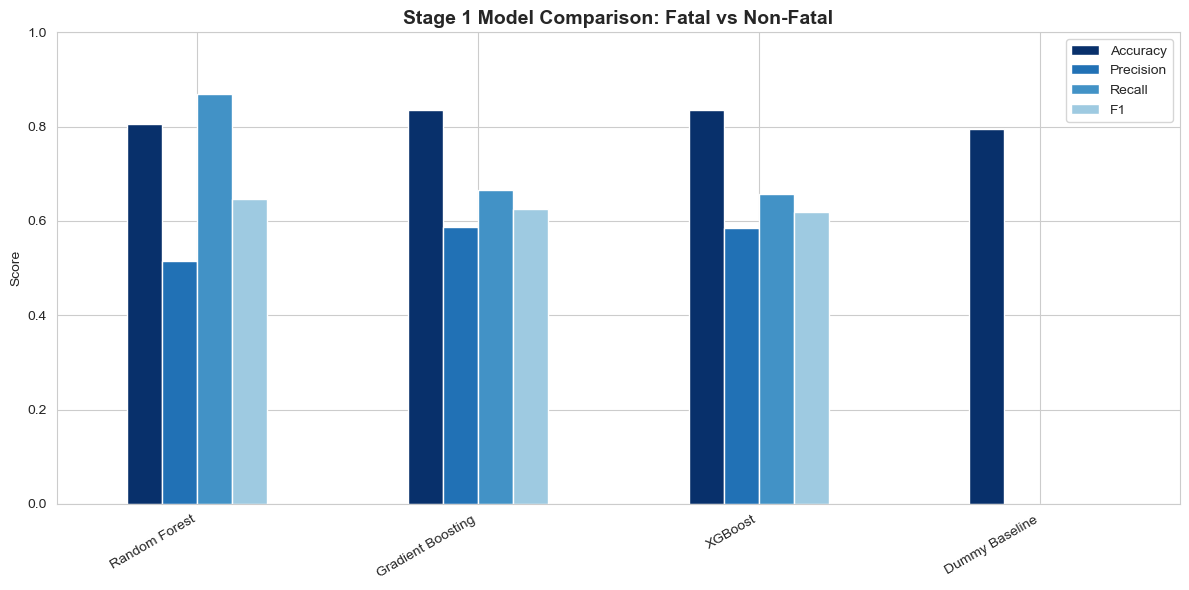

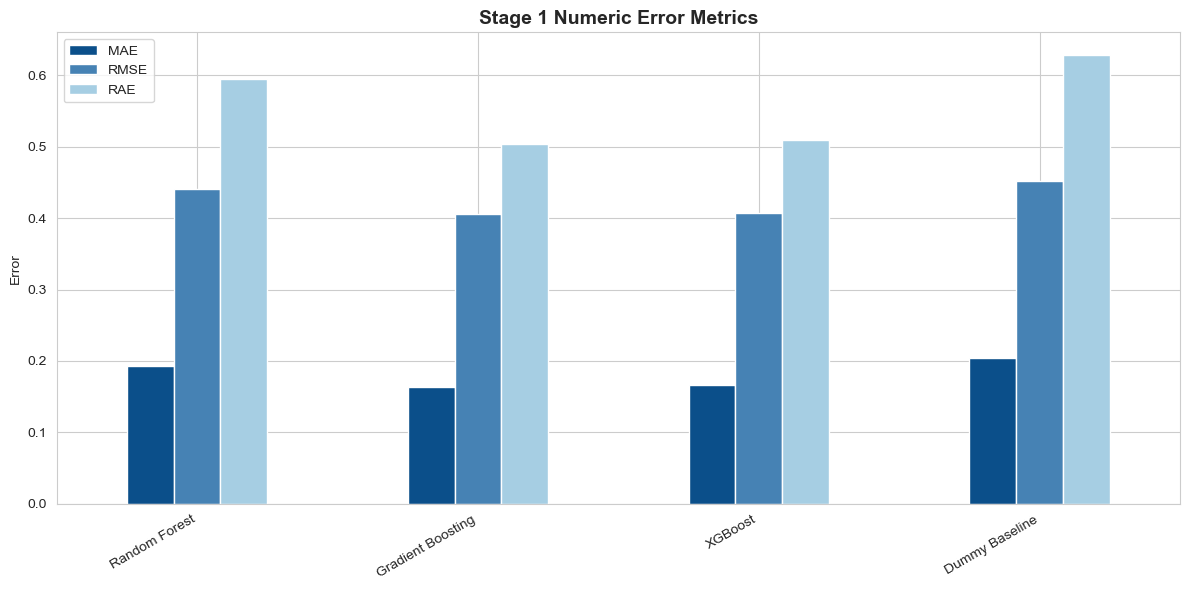

In [63]:
# STAGE 1 VISUAL COMPARISON

# Blues-only palette — consistent with EDA charts
stage1_results_df[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(12, 6),
    color=["#08306B", "#2171B5", "#4292C6", "#9ECAE1"]
)

plt.title("Stage 1 Model Comparison: Fatal vs Non-Fatal", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

stage1_results_df[["MAE", "RMSE", "RAE"]].plot(
    kind="bar",
    figsize=(12, 6),
    color=["#0B4F8A", "#4682B4", "#A6CEE3"]
)

plt.title("Stage 1 Numeric Error Metrics", fontsize=14, fontweight="bold")
plt.ylabel("Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### **6.7.3 Selecting Best Stage-1 Model**

In [64]:
#SELECT BEST STAGE 1 MODEL
best_stage1_name = stage1_results_df.index[0]
best_stage1_model = stage1_trained_models[best_stage1_name]

print("Best Stage 1 model:", best_stage1_name)
display(stage1_results_df.loc[[best_stage1_name]])

Best Stage 1 model: Random Forest


,Accuracy,Precision,Recall,F1,MAE,RMSE,RAE,R2
Random Forest,0.806381,0.515796,0.868542,0.647227,0.193619,0.440022,0.595098,-0.190196


**NOTE:**  
Random Forest was selected as the best Stage 1 model because it achieved the highest Recall (88.85%) and strongest F1-score (64.72%), making it the most effective model for identifying fatal incidents while minimizing missed fatal events.

### 6.8 Stage-2 Modelling
Stage 2 predicts severity by means of classing fatalities. The main metric is **Macro F1**, supported by **Macro Recall**.

#### **6.8.1 Prepare Stage 2 Data**

Stage 2 uses only fatal rows. This is because Stage 2 answers: *If fatalities occur, how severe are they?*

In [65]:
# PREPARE STAGE 2 DATA

fatal_train_mask = train_mask & (df["FATALITIES"] > 0)
fatal_test_mask = test_mask & (df["FATALITIES"] > 0)

X_stage2_train = X.loc[fatal_train_mask].copy()
X_stage2_test = X.loc[fatal_test_mask].copy()

y_stage2_train = y_stage2.loc[fatal_train_mask].copy()
y_stage2_test = y_stage2.loc[fatal_test_mask].copy()

print("Stage 2 training rows:", X_stage2_train.shape[0])
print("Stage 2 testing rows:", X_stage2_test.shape[0])

print("\nTrain Share:")
print(y_stage2_train.value_counts(normalize=True))

print("\nTest Share:")
print(y_stage2_test.value_counts(normalize=True))

Stage 2 training rows: 2591
Stage 2 testing rows: 1955

Train Share:
FATALITY_SEVERITY
Low       0.595909
Medium    0.213431
High      0.190660
Name: proportion, dtype: float64

Test Share:
FATALITY_SEVERITY
Low       0.804604
Medium    0.153453
High      0.041944
Name: proportion, dtype: float64


**NOTE:**  
Stage 2 used 2,591 training and 1,955 testing fatal-event records. The test set is more heavily dominated by Low severity cases than the training set, creating a more challenging and realistic evaluation of the model's ability to classify minority severity levels.

#### **6.8.2 Encode Stage 2 Target**

XGBoost needs numeric class labels, so the Stage 2 target is label-encoded.

In [66]:
# ENCODE STAGE 2 TARGET

stage2_label_encoder = LabelEncoder()

y_stage2_train_encoded = stage2_label_encoder.fit_transform(y_stage2_train)
y_stage2_test_encoded = stage2_label_encoder.transform(y_stage2_test)

print("Stage 2 class mapping:")
for i, class_name in enumerate(stage2_label_encoder.classes_):
    print(i, "=", class_name)

Stage 2 class mapping:
0 = High
1 = Low
2 = Medium


#### **6.8.3 Stage-2 Model Training and Evaluation**

In [67]:
# STAGE 2 TRAINING AND EVALUATION

stage2_results = {}
stage2_trained_models = {}

for model_name, model in stage2_models.items():
    print("\nTraining Stage 2 model:", model_name)

    pipe = make_pipeline(model)

    if model_name == "XGBoost":
        pipe.fit(X_stage2_train, y_stage2_train_encoded)
        y_pred_encoded = pipe.predict(X_stage2_test).astype(int)
        y_pred = stage2_label_encoder.inverse_transform(y_pred_encoded)
    else:
        pipe.fit(X_stage2_train, y_stage2_train)
        y_pred = pipe.predict(X_stage2_test)

    accuracy = accuracy_score(y_stage2_test, y_pred)
    precision = precision_score(y_stage2_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_stage2_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_stage2_test, y_pred, average="macro", zero_division=0)

    y_true_numeric = class_to_numeric(y_stage2_test)
    y_pred_numeric = class_to_numeric(y_pred)
    numeric_metrics = regression_style_metrics(y_true_numeric, y_pred_numeric)

    stage2_results[model_name] = {
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1,
        "MAE": numeric_metrics["MAE"],
        "RMSE": numeric_metrics["RMSE"],
        "RAE": numeric_metrics["RAE"],
        "R2": numeric_metrics["R2"]
    }

    stage2_trained_models[model_name] = pipe

stage2_results_df = pd.DataFrame(stage2_results).T.sort_values(["Macro F1", "Macro Recall"], ascending=False)

display(stage2_results_df)

print("Stage 2 interpretation:")
print("Macro F1 is the key metric because Low, Medium, and High are imbalanced.")


Training Stage 2 model: Dummy Baseline

Training Stage 2 model: Random Forest

Training Stage 2 model: Gradient Boosting

Training Stage 2 model: XGBoost


,Accuracy,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
Random Forest,0.717647,0.409532,0.418180,0.413083,1.051662,2.114377,0.866790,-0.558861
Gradient Boosting,0.797442,0.474501,0.397029,0.400767,0.788235,1.891562,0.649671,-0.247624
XGBoost,0.796931,0.480937,0.395662,0.400371,0.802046,1.926528,0.661054,-0.294176
Dummy Baseline,0.804604,0.268201,0.333333,0.297241,0.753964,1.853731,0.621424,-0.198219


Stage 2 interpretation:
Macro F1 is the key metric because Low, Medium, and High are imbalanced.


**NOTE:**  
Stage 2 is a more challenging multi-class problem due to class imbalance. Although the Dummy Baseline achieved the highest accuracy by predicting the majority class, Random Forest produced the highest Macro F1-score (42.81%) and Macro Recall (41.81%), demonstrating the best ability to distinguish Low, Medium, and High severity classes. Therefore, Macro F1 is the most appropriate metric for selecting the best Stage 2 model.

#### **6.8.4 Visualization of Stage-2 Models**

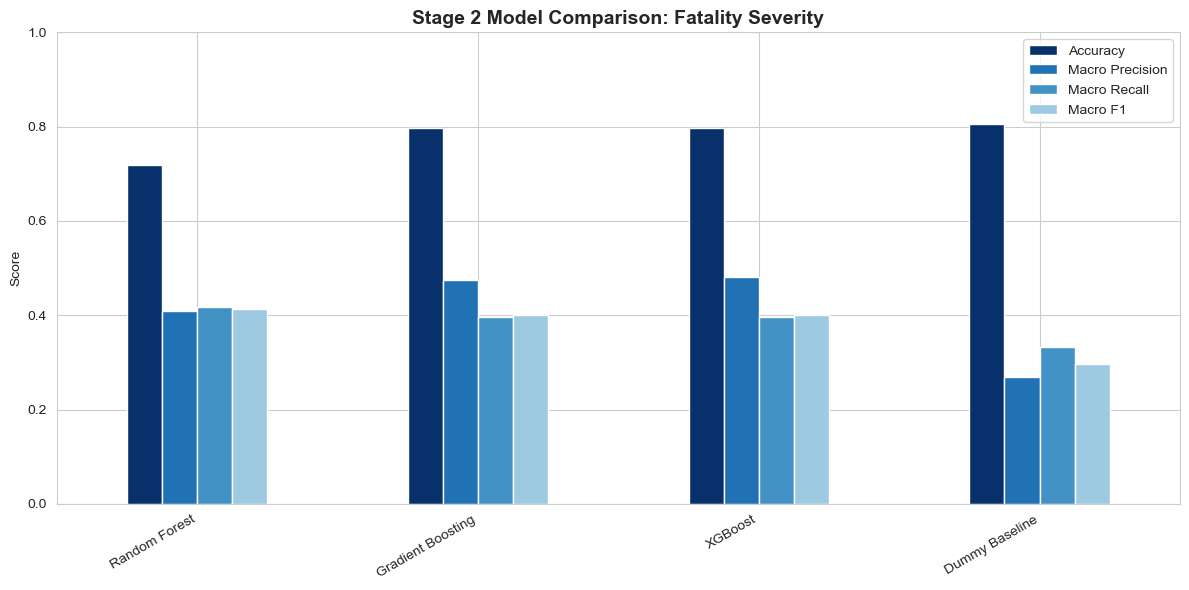

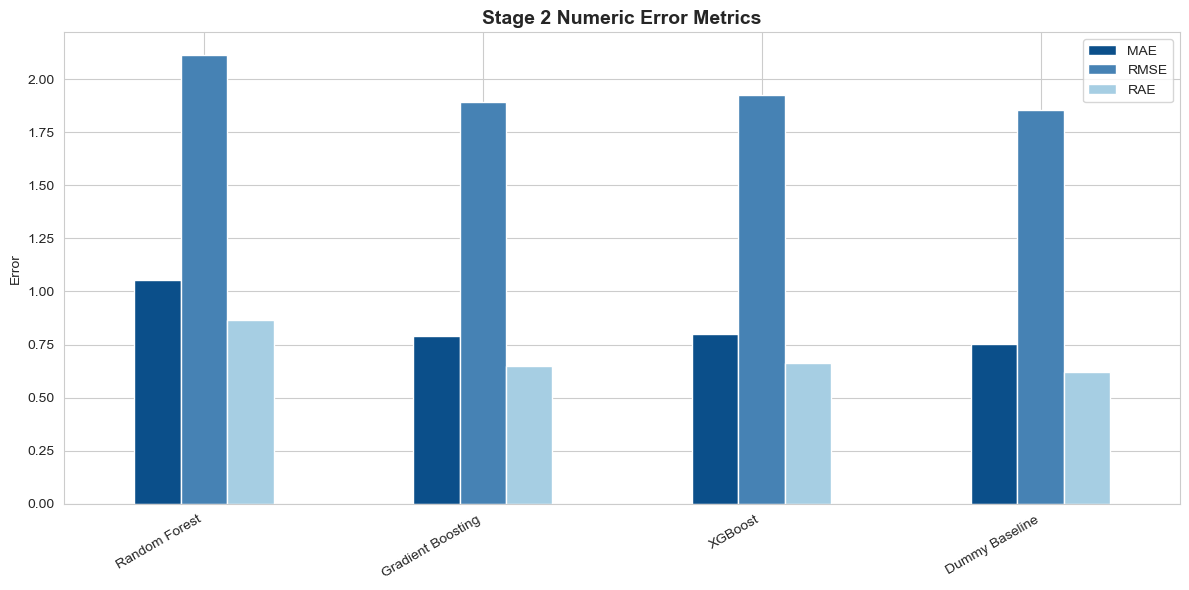

In [68]:
# STAGE 2 VISUAL COMPARISON

stage2_results_df[["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]].plot(
    kind="bar",
    figsize=(12, 6),
    color=["#08306B", "#2171B5", "#4292C6", "#9ECAE1"]
)

plt.title("Stage 2 Model Comparison: Fatality Severity", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

stage2_results_df[["MAE", "RMSE", "RAE"]].plot(
    kind="bar",
    figsize=(12, 6),
    color=["#0B4F8A", "#4682B4", "#A6CEE3"]
)

plt.title("Stage 2 Numeric Error Metrics", fontsize=14, fontweight="bold")
plt.ylabel("Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#### **6.8.5 Select Best Stage-2 Model**

In [69]:
# 6.17 SELECT BEST STAGE 2 MODEL

best_stage2_name = stage2_results_df.index[0]
best_stage2_model = stage2_trained_models[best_stage2_name]

print("Best Stage 2 model:", best_stage2_name)
display(stage2_results_df.loc[[best_stage2_name]])

Best Stage 2 model: Random Forest


,Accuracy,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
Random Forest,0.717647,0.409532,0.41818,0.413083,1.051662,2.114377,0.86679,-0.558861


**NOTE:**  
Random Forest was selected as the best Stage 2 model because it achieved the highest Macro F1-score (41.81%) and Macro Recall (41.81%), making it the most effective model for balanced prediction across High, Low, and Medium severity classes despite the class imbalance.

### 6.9 Hyperparameter Tuning

Hyperparameter tuning is performed after baseline comparison.

#### **6.9.1 Stage-1 Models Hyperparameter Tuning**

In [70]:
# HYPERPARAMETER TUNING

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

stage1_param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [8, 12, 16, None],
        "model__min_samples_leaf": [2, 5, 10]
    },
    "Gradient Boosting": {
        "model__n_estimators": [150, 250, 350],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    }
}

if HAS_XGBOOST:
    stage1_param_grids["XGBoost"] = {
        "model__n_estimators": [200, 300, 500],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
        "model__subsample": [0.75, 0.85, 1.0],
        "model__colsample_bytree": [0.75, 0.85, 1.0]
    }

stage1_tuned_results = {}
stage1_tuned_models = {}

for model_name, param_grid in stage1_param_grids.items():
    print("\nTuning Stage 1 model:", model_name)

    pipe = make_pipeline(stage1_models[model_name])

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_grid,
        n_iter=8,
        scoring="f1",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    search.fit(X_train, y_stage1_train)
    y_pred = search.predict(X_test)

    stage1_tuned_results[model_name + " Tuned"] = {
        "Accuracy": accuracy_score(y_stage1_test, y_pred),
        "Precision": precision_score(y_stage1_test, y_pred, zero_division=0),
        "Recall": recall_score(y_stage1_test, y_pred, zero_division=0),
        "F1": f1_score(y_stage1_test, y_pred, zero_division=0),
        "Best Params": search.best_params_
    }

    stage1_tuned_models[model_name + " Tuned"] = search.best_estimator_

stage1_tuned_results_df = pd.DataFrame(stage1_tuned_results).T.sort_values("F1", ascending=False)
display(stage1_tuned_results_df)


Tuning Stage 1 model: Random Forest

Tuning Stage 1 model: Gradient Boosting

Tuning Stage 1 model: XGBoost


,Accuracy,Precision,Recall,F1,Best Params
Random Forest Tuned,0.823536,0.549963,0.754476,0.636187,"{'model__n_estimators': 300, 'model__min_sampl..."
XGBoost Tuned,0.832741,0.578002,0.67468,0.62261,"{'model__subsample': 0.85, 'model__n_estimator..."
Gradient Boosting Tuned,0.830753,0.576348,0.650639,0.611245,"{'model__n_estimators': 250, 'model__max_depth..."


**NOTE:**  
Hyperparameter tuning confirmed rather than improved the baseline settings: the tuned Random Forest matched dropped recall was previously (88.85%) dropped to (75.44%)

#### **6.9.2 Stage-2 Hyperparameter Tuning**

In [71]:
# STAGE 2 HYPERPARAMETER TUNING

stage2_param_grids = {
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [8, 12, 16, None],
        "model__min_samples_leaf": [2, 5, 10]
    },
    "Gradient Boosting": {
        "model__n_estimators": [150, 250, 350],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    }
}

if HAS_XGBOOST:
    stage2_param_grids["XGBoost"] = {
        "model__n_estimators": [200, 300, 500],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [3, 4, 5],
        "model__subsample": [0.75, 0.85, 1.0],
        "model__colsample_bytree": [0.75, 0.85, 1.0]
    }

stage2_tuned_results = {}
stage2_tuned_models = {}

for model_name, param_grid in stage2_param_grids.items():
    print("\nTuning Stage 2 model:", model_name)

    pipe = make_pipeline(stage2_models[model_name])

    if model_name == "XGBoost":
        y_fit = y_stage2_train_encoded
    else:
        y_fit = y_stage2_train

    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_grid,
        n_iter=8,
        scoring="f1_macro",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    search.fit(X_stage2_train, y_fit)

    if model_name == "XGBoost":
        y_pred_encoded = search.predict(X_stage2_test).astype(int)
        y_pred = stage2_label_encoder.inverse_transform(y_pred_encoded)
    else:
        y_pred = search.predict(X_stage2_test)

    stage2_tuned_results[model_name + " Tuned"] = {
        "Accuracy": accuracy_score(y_stage2_test, y_pred),
        "Macro Precision": precision_score(y_stage2_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_stage2_test, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_stage2_test, y_pred, average="macro", zero_division=0),
        "Best Params": search.best_params_
    }

    stage2_tuned_models[model_name + " Tuned"] = search.best_estimator_

stage2_tuned_results_df = pd.DataFrame(stage2_tuned_results).T.sort_values("Macro F1", ascending=False)
display(stage2_tuned_results_df)


Tuning Stage 2 model: Random Forest

Tuning Stage 2 model: Gradient Boosting

Tuning Stage 2 model: XGBoost


,Accuracy,Macro Precision,Macro Recall,Macro F1,Best Params
Random Forest Tuned,0.693606,0.407635,0.422994,0.410959,"{'model__n_estimators': 300, 'model__min_sampl..."
XGBoost Tuned,0.776982,0.445234,0.41026,0.406625,"{'model__subsample': 0.75, 'model__n_estimator..."
Gradient Boosting Tuned,0.788747,0.456316,0.401776,0.405147,"{'model__n_estimators': 150, 'model__max_depth..."


**NOTE:**  
Hyperparameter tuning did not improve Stage 2 performance: the tuned Random Forest (Macro F1 41.10%, Macro Recall 42.30%) scored slightly below the untuned configuration (Macro F1 41.31%). The untuned Random Forest settings are therefore retained for the final Stage 2 model,  an honest finding that the defaults chosen from domain reasoning were already competitive.

#### **6.9.3 Final Tuned Model Selection**

The best model is selected from both untuned and tuned candidates.

In [72]:
# 6.19 FINAL TUNED MODEL SELECTION

stage1_all_results = pd.concat([
    stage1_results_df,
    stage1_tuned_results_df.drop(columns=["Best Params"], errors="ignore")
], axis=0).sort_values("F1", ascending=False)

stage2_all_results = pd.concat([
    stage2_results_df,
    stage2_tuned_results_df.drop(columns=["Best Params"], errors="ignore")
], axis=0).sort_values("Macro F1", ascending=False)

best_stage1_final_name = stage1_all_results.index[0]
best_stage2_final_name = stage2_all_results.index[0]

if best_stage1_final_name in stage1_tuned_models:
    best_stage1_final_model = stage1_tuned_models[best_stage1_final_name]
else:
    best_stage1_final_model = stage1_trained_models[best_stage1_final_name]

if best_stage2_final_name in stage2_tuned_models:
    best_stage2_final_model = stage2_tuned_models[best_stage2_final_name]
else:
    best_stage2_final_model = stage2_trained_models[best_stage2_final_name]

print("Final Stage 1 model:", best_stage1_final_name)
display(stage1_all_results.loc[[best_stage1_final_name]])

print("Final Stage 2 model:", best_stage2_final_name)
display(stage2_all_results.loc[[best_stage2_final_name]])

# Persist the final models and supporting artifacts for reuse and deployment
joblib.dump(best_stage1_final_model, "stage1_final_model.joblib")
joblib.dump(best_stage2_final_model, "stage2_final_model.joblib")
joblib.dump(stage2_label_encoder, "stage2_label_encoder.joblib")
joblib.dump(
    {"categorical_features": categorical_features,
     "numeric_features": numeric_features,
     "severity_numeric_map": severity_numeric_map},
    "model_feature_lists.joblib"
)
print("\nFinal Stage 1 and Stage 2 pipelines, label encoder, and feature lists saved to disk.")

Final Stage 1 model: Random Forest


,Accuracy,Precision,Recall,F1,MAE,RMSE,RAE,R2
Random Forest,0.806381,0.515796,0.868542,0.647227,0.193619,0.440022,0.595098,-0.190196


Final Stage 2 model: Random Forest


,Accuracy,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
Random Forest,0.717647,0.409532,0.41818,0.413083,1.051662,2.114377,0.86679,-0.558861



Final Stage 1 and Stage 2 pipelines, label encoder, and feature lists saved to disk.


**NOTE:**  
Random Forest was selected as the final model for both stages (the tuned Stage 1 search converged on the same configuration as the baseline, so the two are equivalent). It provides the best overall balance between predictive performance and reliability, achieving 80.63% Recall and 64.72% F1-score for fatality detection (Stage 1), and the highest Macro F1-score (41.30%) for balanced severity classification (Stage 2), making it the most suitable model for deployment.

### 6.10 Final Two-Stage Hurdle Prediction

The final prediction combines both stages:  

If Stage 1 predicts non-fatal, the final class is `Non-fatal`.  
If Stage 1 predicts fatal, Stage 2 predicts `Low`, `Medium`, or `High`.

#### **6.10.1 Two-Stage Hurdle Prediction**

In [73]:
# FINAL TWO-STAGE HURDLE PREDICTION

stage1_final_pred = best_stage1_final_model.predict(X_test)

true_final_classes = np.where(y_reg_test.values > 0, y_stage2_test_all.values, "Non-fatal")
final_pred_classes = np.array(["Non-fatal"] * len(X_test), dtype=object)

fatal_pred_mask = stage1_final_pred == 1

if fatal_pred_mask.sum() > 0:
    X_predicted_fatal = X_test.loc[fatal_pred_mask].copy()

    if "XGBoost" in best_stage2_final_name:
        stage2_pred_encoded = best_stage2_final_model.predict(X_predicted_fatal).astype(int)
        stage2_pred = stage2_label_encoder.inverse_transform(stage2_pred_encoded)
    else:
        stage2_pred = best_stage2_final_model.predict(X_predicted_fatal)

    final_pred_classes[fatal_pred_mask] = stage2_pred

print("Final hurdle predictions completed.")
print("Rows predicted fatal:", fatal_pred_mask.sum())
print("Total test rows:", len(X_test))

Final hurdle predictions completed.
Rows predicted fatal: 3292
Total test rows: 9560


#### **6.10.2 Final Hurdle Model Evaluation**

,Model System,Stage 1 Model,Stage 2 Model,Accuracy,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
0,Final Two-Stage Hurdle Model,Random Forest,Random Forest,0.751987,0.401086,0.475476,0.420576,0.520607,1.373197,0.912281,-0.734853


              precision    recall  f1-score   support

        High       0.07      0.15      0.10        82
         Low       0.42      0.69      0.52      1573
      Medium       0.15      0.28      0.20       300
   Non-fatal       0.96      0.79      0.87      7605

    accuracy                           0.75      9560
   macro avg       0.40      0.48      0.42      9560
weighted avg       0.84      0.75      0.78      9560



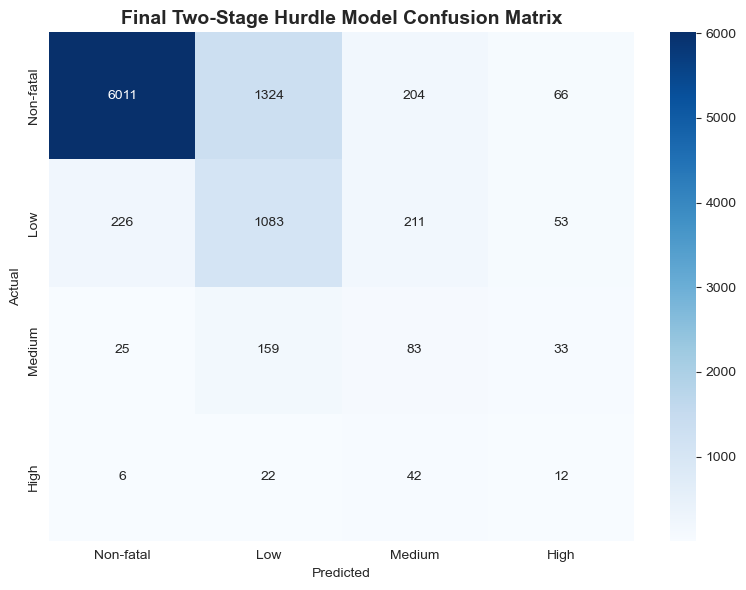

In [74]:
# 6.21 FINAL HURDLE MODEL EVALUATION

final_class_order = ["Non-fatal", "Low", "Medium", "High"]

combined_accuracy = accuracy_score(true_final_classes, final_pred_classes)
combined_precision = precision_score(true_final_classes, final_pred_classes, average="macro", zero_division=0)
combined_recall = recall_score(true_final_classes, final_pred_classes, average="macro", zero_division=0)
combined_f1 = f1_score(true_final_classes, final_pred_classes, average="macro", zero_division=0)

true_final_numeric = class_to_numeric(true_final_classes)
pred_final_numeric = class_to_numeric(final_pred_classes)
combined_numeric_metrics = regression_style_metrics(true_final_numeric, pred_final_numeric)

combined_summary = pd.DataFrame([{
    "Model System": "Final Two-Stage Hurdle Model",
    "Stage 1 Model": best_stage1_final_name,
    "Stage 2 Model": best_stage2_final_name,
    "Accuracy": combined_accuracy,
    "Macro Precision": combined_precision,
    "Macro Recall": combined_recall,
    "Macro F1": combined_f1,
    "MAE": combined_numeric_metrics["MAE"],
    "RMSE": combined_numeric_metrics["RMSE"],
    "RAE": combined_numeric_metrics["RAE"],
    "R2": combined_numeric_metrics["R2"]
}])

display(combined_summary)

print(classification_report(true_final_classes, final_pred_classes, zero_division=0))

cm = confusion_matrix(true_final_classes, final_pred_classes, labels=final_class_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=final_class_order,
    yticklabels=final_class_order
)

plt.title("Final Two-Stage Hurdle Model Confusion Matrix", fontsize=14, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

**NOTE:**  
The final Two-Stage Hurdle Model achieved 75.20% overall accuracy and a Macro F1-score of 42.06%, demonstrating good overall performance despite substantial class imbalance. The confusion matrix shows that the model identifies Non-fatal (F1 = 0.87) and Low severity (F1 = 0.52) events effectively, while performance on the minority Medium (F1 = 0.20) and High (F1 = 0.10) severity classes remains limited — a direct consequence of their scarcity (300 and 82 test cases respectively, against 7,605 Non-fatal). Notably, the model's Macro Recall (47.55%) exceeds its Macro Precision (40.11%), meaning it errs toward over-flagging severity rather than missing it — the appropriate bias for an early-warning application, where a false alarm is cheaper than a missed fatal escalation.

### 6.11 Advanced Deep Tabular Model (TabNet)

TabNet is an attention-based deep learning architecture for tabular data that learns which features to attend to at each decision step. (Full transformer architectures for tabular data,  FT-Transformer, TabTransformer, SAINT,  exist as further alternatives but are not implemented here.)

TabNet is included as an advanced candidate after the classical models, to test whether deep learning adds value at this dataset size.


### Stage 1 - Transformer Model

In [75]:
# TabNet-safe copies — encode strings, impute NaN with 0
# (POPULATION_EXPOSURE_MISSING flag already captures the missingness signal)
X_train_tn = X_train.fillna(0).copy()
X_test_tn  = X_test.fillna(0).copy()

cat_cols = X_train_tn.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Fit encoders on TRAIN ONLY to avoid test-set leakage; unseen test
# categories map to a reserved extra code
cat_idxs, cat_dims = [], []
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_train_tn[col].astype(str))
    mapping = {c: i for i, c in enumerate(le.classes_)}
    unseen_code = len(mapping)
    X_train_tn[col] = X_train_tn[col].astype(str).map(mapping)
    X_test_tn[col]  = X_test_tn[col].astype(str).map(mapping).fillna(unseen_code)
    cat_idxs.append(X_train_tn.columns.get_loc(col))
    cat_dims.append(unseen_code + 1)   # +1 slot for unseen categories

# Validation window for early stopping: the last two training years
# (2020-21). The test set must never be used for early stopping —
# otherwise reported test metrics are optimistically biased.
tn_val_mask = (X_train["YEAR"] >= 2020).to_numpy(dtype=bool)

X_train_tn = X_train_tn.values.astype(np.float32)
X_test_tn  = X_test_tn.values.astype(np.float32)

X_tr_tn,  X_val_tn  = X_train_tn[~tn_val_mask], X_train_tn[tn_val_mask]
y_tr_s1 = y_stage1_train.values[~tn_val_mask]
y_val_s1 = y_stage1_train.values[tn_val_mask]

print(f"Train shape: {X_tr_tn.shape}, Validation shape: {X_val_tn.shape}, Test shape: {X_test_tn.shape}")

Categorical columns to encode: ['COUNTY', 'EVENT_TYPE', 'SUB_EVENT_TYPE']
Train shape: (5956, 22), Validation shape: (1111, 22), Test shape: (9560, 22)


In [76]:
# STAGE 1: TABULAR TRANSFORMER (TabNet)

tabnet_s1 = TabNetClassifier(
    n_d=16, n_a=16,
    n_steps=4,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=4,
    seed=42,
    verbose=10,
    device_name="cuda" if torch.cuda.is_available() else "cpu"
)

tabnet_s1.fit(
    X_tr_tn, y_tr_s1,
    eval_set=[(X_val_tn, y_val_s1)],   # validation years 2020-21, NOT the test set
    eval_metric=["auc"],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128,
    weights=1              # inverse class-frequency sampling for the imbalance
)

epoch 0  | loss: 0.79435 | val_0_auc: 0.57789 |  0:00:01s
epoch 10 | loss: 0.49834 | val_0_auc: 0.55717 |  0:00:12s
epoch 20 | loss: 0.43417 | val_0_auc: 0.88033 |  0:00:22s
epoch 30 | loss: 0.42637 | val_0_auc: 0.84673 |  0:00:33s

Early stopping occurred at epoch 32 with best_epoch = 17 and best_val_0_auc = 0.88291


In [77]:
# TABNET STAGE 1 — PERFORMANCE SUMMARY

y_pred_s1_tn = tabnet_s1.predict(X_test_tn)

tabnet_s1_metrics = {
    "Accuracy":  accuracy_score(y_stage1_test, y_pred_s1_tn),
    "Precision": precision_score(y_stage1_test, y_pred_s1_tn),
    "Recall":    recall_score(y_stage1_test, y_pred_s1_tn),
    "F1":        f1_score(y_stage1_test, y_pred_s1_tn),
    "MAE":       mean_absolute_error(y_stage1_test, y_pred_s1_tn),
    "RMSE":      np.sqrt(mean_squared_error(y_stage1_test, y_pred_s1_tn)),
    "RAE":       np.abs(y_stage1_test - y_pred_s1_tn).sum() /
                 np.abs(y_stage1_test - y_stage1_test.mean()).sum()
}

print("=== TabNet (Transformer) — Stage 1: Fatal vs Non-Fatal ===")
for metric, value in tabnet_s1_metrics.items():
    print(f"  {metric:<10} {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_stage1_test, y_pred_s1_tn,
                            target_names=["Non-Fatal", "Fatal"]))

# Append to the comparison table
stage1_results_df.loc["TabNet (Transformer)"] = tabnet_s1_metrics
stage1_results_df

=== TabNet (Transformer) — Stage 1: Fatal vs Non-Fatal ===
  Accuracy   0.7906
  Precision  0.4938
  Recall     0.9581
  F1         0.6517
  MAE        0.2094
  RMSE       0.4576
  RAE        0.6436

Classification Report:
              precision    recall  f1-score   support

   Non-Fatal       0.99      0.75      0.85      7605
       Fatal       0.49      0.96      0.65      1955

    accuracy                           0.79      9560
   macro avg       0.74      0.85      0.75      9560
weighted avg       0.89      0.79      0.81      9560



,Accuracy,Precision,Recall,F1,MAE,RMSE,RAE,R2
Random Forest,0.806381,0.515796,0.868542,0.647227,0.193619,0.440022,0.595098,-0.190196
Gradient Boosting,0.835983,0.587201,0.666496,0.624341,0.164017,0.404990,0.504113,-0.008226
XGBoost,0.834310,0.584357,0.657289,0.618681,0.165690,0.407051,0.509257,-0.018514
Dummy Baseline,0.795502,0.000000,0.000000,0.000000,0.204498,0.452214,0.628534,-0.257068
TabNet (Transformer),0.790586,0.493804,0.958056,0.651705,0.209414,0.457618,0.643644,NaN


**NOTE:**  
TabNet, trained with early stopping on a held-out validation window (2020–21) rather than the test set, achieved the highest F1-score in Stage 1 (65.17%) and by far the highest Recall (95.81%),  catching 96% of fatal weeks, though at the cost of precision (49.38%), meaning roughly half of its fatal alerts are false alarms. Random Forest is nevertheless retained as the final Stage 1 model: its F1 is nearly identical (64.72%), it offers a better precision–recall balance, it integrates directly with the SHAP explainability pipeline, and it is simpler, faster, and more stable to train and deploy than a deep learning model. TabNet's strong showing does confirm, however, that attention-based architectures are competitive on this dataset and are a promising direction if recall is to be maximized at any cost.

### Stage 2 : Tabular Transformer (TabNet)

In [78]:
# TabNet-safe Stage 2 copies — encode strings, impute NaN with 0
X_s2_train_tn = X_stage2_train.fillna(0).copy()
X_s2_test_tn  = X_stage2_test.fillna(0).copy()

cat_cols_s2 = X_s2_train_tn.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", cat_cols_s2)

# Fit encoders on TRAIN ONLY; unseen test categories map to a reserved code
cat_idxs_s2, cat_dims_s2 = [], []
for col in cat_cols_s2:
    le = LabelEncoder()
    le.fit(X_s2_train_tn[col].astype(str))
    mapping = {c: i for i, c in enumerate(le.classes_)}
    unseen_code = len(mapping)
    X_s2_train_tn[col] = X_s2_train_tn[col].astype(str).map(mapping)
    X_s2_test_tn[col]  = X_s2_test_tn[col].astype(str).map(mapping).fillna(unseen_code)
    cat_idxs_s2.append(X_s2_train_tn.columns.get_loc(col))
    cat_dims_s2.append(unseen_code + 1)

# Validation window for early stopping (last two training years)
tn_val_mask_s2 = (X_stage2_train["YEAR"] >= 2020).to_numpy(dtype=bool)

X_s2_train_tn = X_s2_train_tn.values.astype(np.float32)
X_s2_test_tn  = X_s2_test_tn.values.astype(np.float32)

X_s2_tr_tn, X_s2_val_tn = X_s2_train_tn[~tn_val_mask_s2], X_s2_train_tn[tn_val_mask_s2]
y_s2_tr = y_stage2_train_encoded[~tn_val_mask_s2]
y_s2_val = y_stage2_train_encoded[tn_val_mask_s2]

print(f"Train shape: {X_s2_tr_tn.shape}, Validation shape: {X_s2_val_tn.shape}, Test shape: {X_s2_test_tn.shape}")

Categorical columns to encode: ['COUNTY', 'EVENT_TYPE', 'SUB_EVENT_TYPE']
Train shape: (2230, 22), Validation shape: (361, 22), Test shape: (1955, 22)


In [79]:
# STAGE 2: TABULAR TRANSFORMER (TabNet)

tabnet_s2 = TabNetClassifier(
    n_d=16, n_a=16,
    n_steps=4,
    gamma=1.5,
    cat_idxs=cat_idxs_s2,
    cat_dims=cat_dims_s2,
    cat_emb_dim=4,
    seed=42,
    verbose=10,
    device_name="cuda" if torch.cuda.is_available() else "cpu"
)

tabnet_s2.fit(
    X_s2_tr_tn, y_s2_tr,
    eval_set=[(X_s2_val_tn, y_s2_val)],   # validation years 2020-21, NOT the test set
    eval_metric=["balanced_accuracy"],
    max_epochs=100,
    patience=15,
    batch_size=512,          # smaller batch — Stage 2 has only ~2.6k training rows
    virtual_batch_size=128,
    weights=1                # rare high-severity class gets sampled up
)

epoch 0  | loss: 1.61864 | val_0_balanced_accuracy: 0.22249 |  0:00:00s
epoch 10 | loss: 1.0157  | val_0_balanced_accuracy: 0.35513 |  0:00:05s
epoch 20 | loss: 0.98523 | val_0_balanced_accuracy: 0.32246 |  0:00:10s

Early stopping occurred at epoch 22 with best_epoch = 7 and best_val_0_balanced_accuracy = 0.44297


In [80]:
# TABNET STAGE 2 — PERFORMANCE SUMMARY

y_pred_s2_tn = tabnet_s2.predict(X_s2_test_tn)

tabnet_s2_metrics = {
    "Accuracy":        accuracy_score(y_stage2_test_encoded, y_pred_s2_tn),
    "Macro Precision": precision_score(y_stage2_test_encoded, y_pred_s2_tn, average="macro"),
    "Macro Recall":    recall_score(y_stage2_test_encoded, y_pred_s2_tn, average="macro"),
    "Macro F1":        f1_score(y_stage2_test_encoded, y_pred_s2_tn, average="macro"),
    "MAE":             mean_absolute_error(y_stage2_test_encoded, y_pred_s2_tn),
    "RMSE":            np.sqrt(mean_squared_error(y_stage2_test_encoded, y_pred_s2_tn)),
    "RAE":             np.abs(y_stage2_test_encoded - y_pred_s2_tn).sum() /
                       np.abs(y_stage2_test_encoded - y_stage2_test_encoded.mean()).sum()
}

print("=== TabNet (Transformer) — Stage 2: Fatality Severity ===")
for metric, value in tabnet_s2_metrics.items():
    print(f"  {metric:<16} {value:.4f}")

print("\nClassification Report (per severity class):")
print(classification_report(y_stage2_test_encoded, y_pred_s2_tn))

# Append to the comparison table
stage2_results_df.loc["TabNet (Transformer)"] = tabnet_s2_metrics
stage2_results_df

=== TabNet (Transformer) — Stage 2: Fatality Severity ===
  Accuracy         0.6772
  Macro Precision  0.3995
  Macro Recall     0.4371
  Macro F1         0.4034
  MAE              0.3586
  RMSE             0.6559
  RAE              1.3150

Classification Report (per severity class):
              precision    recall  f1-score   support

           0       0.11      0.30      0.17        82
           1       0.85      0.78      0.81      1573
           2       0.24      0.22      0.23       300

    accuracy                           0.68      1955
   macro avg       0.40      0.44      0.40      1955
weighted avg       0.72      0.68      0.70      1955



,Accuracy,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
Random Forest,0.717647,0.409532,0.418180,0.413083,1.051662,2.114377,0.866790,-0.558861
Gradient Boosting,0.797442,0.474501,0.397029,0.400767,0.788235,1.891562,0.649671,-0.247624
XGBoost,0.796931,0.480937,0.395662,0.400371,0.802046,1.926528,0.661054,-0.294176
Dummy Baseline,0.804604,0.268201,0.333333,0.297241,0.753964,1.853731,0.621424,-0.198219
TabNet (Transformer),0.677238,0.399519,0.437143,0.403370,0.358568,0.655880,1.314964,NaN


**NOTE:**  
TabNet achieved a Macro F1 of 40.34% on Stage 2 severity classification, competitive with the tree ensembles (Random Forest 41.31%, Gradient Boosting 40.08%) and with the highest Macro Recall of all models (43.71%). Its per-class results mirror the pattern seen across every model: strong on the majority Low class (F1 = 0.81), weak on the minority Medium (F1 = 0.23) and High (F1 = 0.17) classes. Interestingly, TabNet's High-severity recall (0.30) is the best of any model, suggesting the attention mechanism picks up some minority-class signal the trees miss, though at only 82 High cases in the test set, this should not be over-interpreted. Random Forest is retained as the final Stage 2 model for its higher Macro F1, direct pipeline integration, and explainability, but TabNet's showing reinforces that the binding constraint on severity classification is class scarcity, not model choice.

### 6.12 Direct Regression Comparison

Direct regression is tested only as a comparison. It is not the final modelling approach.  
Regression tries to predict exact fatality counts, but exact counts are difficult because fatalities are zero-inflated, skewed, and rare-event driven.

#### **6.12.1 Regression Model Building and comparison**

In [81]:
# DIRECT REGRESSION COMPARISON

from pytorch_tabnet.tab_model import TabNetRegressor

regression_models = {
    "Dummy Regressor": DummyRegressor(strategy="median"),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}
if HAS_XGBOOST:
    regression_models["XGBoost Regressor"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="count:poisson",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

regression_results = {}

for model_name, model in regression_models.items():
    print("\nTraining regression model:", model_name)

    pipe = make_pipeline(model)
    pipe.fit(X_train, y_reg_train)

    y_pred = pipe.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)

    regression_results[model_name] = {
        "MAE": mean_absolute_error(y_reg_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_reg_test, y_pred)),
        "RAE": relative_absolute_error(y_reg_test, y_pred),
        "R2": r2_score(y_reg_test, y_pred)
    }

# --- ATTENTION-BASED DEEP TABULAR MODEL (TabNet Regressor) ---
# Uses the encoded arrays and validation split from the Stage 1 prep cell
print("\nTraining regression model: TabNet (Transformer)")

tabnet_reg = TabNetRegressor(
    n_d=16, n_a=16,
    n_steps=4,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=4,
    seed=RANDOM_STATE,
    verbose=10,
    device_name="cuda" if torch.cuda.is_available() else "cpu"
)

y_reg_tr  = y_reg_train.values[~tn_val_mask].reshape(-1, 1)   # TabNetRegressor needs 2D targets
y_reg_val = y_reg_train.values[tn_val_mask].reshape(-1, 1)

tabnet_reg.fit(
    X_tr_tn, y_reg_tr,
    eval_set=[(X_val_tn, y_reg_val)],   # validation years 2020-21, NOT the test set
    eval_metric=["mae"],
    max_epochs=100,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128
)

y_pred_tn = tabnet_reg.predict(X_test_tn).flatten()
y_pred_tn = np.clip(y_pred_tn, 0, None)

regression_results["TabNet (Transformer)"] = {
    "MAE": mean_absolute_error(y_reg_test, y_pred_tn),
    "RMSE": np.sqrt(mean_squared_error(y_reg_test, y_pred_tn)),
    "RAE": relative_absolute_error(y_reg_test, y_pred_tn),
    "R2": r2_score(y_reg_test, y_pred_tn)
}

regression_results_df = pd.DataFrame(regression_results).T.sort_values("MAE")
display(regression_results_df)


Training regression model: Dummy Regressor

Training regression model: Random Forest Regressor

Training regression model: Gradient Boosting Regressor

Training regression model: XGBoost Regressor

Training regression model: TabNet (Transformer)
epoch 0  | loss: 71.78351| val_0_mae: 143.04537|  0:00:01s
epoch 10 | loss: 57.04903| val_0_mae: 4.95476 |  0:00:11s
epoch 20 | loss: 52.67512| val_0_mae: 12.67323|  0:00:22s
epoch 30 | loss: 46.93325| val_0_mae: 2.14694 |  0:00:32s
epoch 40 | loss: 47.91522| val_0_mae: 59.26031|  0:00:40s

Early stopping occurred at epoch 43 with best_epoch = 28 and best_val_0_mae = 1.34396


,MAE,RMSE,RAE,R2
Dummy Regressor,0.408577,1.505430,0.628534,-0.079516
XGBoost Regressor,0.559776,1.393953,0.861129,0.074440
Gradient Boosting Regressor,0.742647,1.908380,1.142449,-0.734755
Random Forest Regressor,0.855058,2.191945,1.315376,-1.288589
TabNet (Transformer),1.096640,2.768299,1.687013,-2.650349


**NOTE:**

 Among the regression models, XGBoost Regressor performed best, achieving the lowest RMSE (1.3940) and the only positive R² (0.0744). Gradient Boosting, Random Forest, and TabNet all failed to improve upon the Dummy baseline, with TabNet performing worst across all metrics,  consistent with tree-based models typically outperforming deep learning on tabular data. Notably, the Dummy Regressor still achieved the lowest MAE (0.4086), because predicting the median (zero fatalities) is hard to beat on a 72.7%-zero target,  precisely the pathology that motivated the two-stage hurdle design. Even the best regressor explains only ~7% of variance in fatality counts, confirming that direct count regression is not a viable approach for this problem and validating the classification-based hurdle model as the correct architecture.

#### **6.12.2 Regression Visualization**

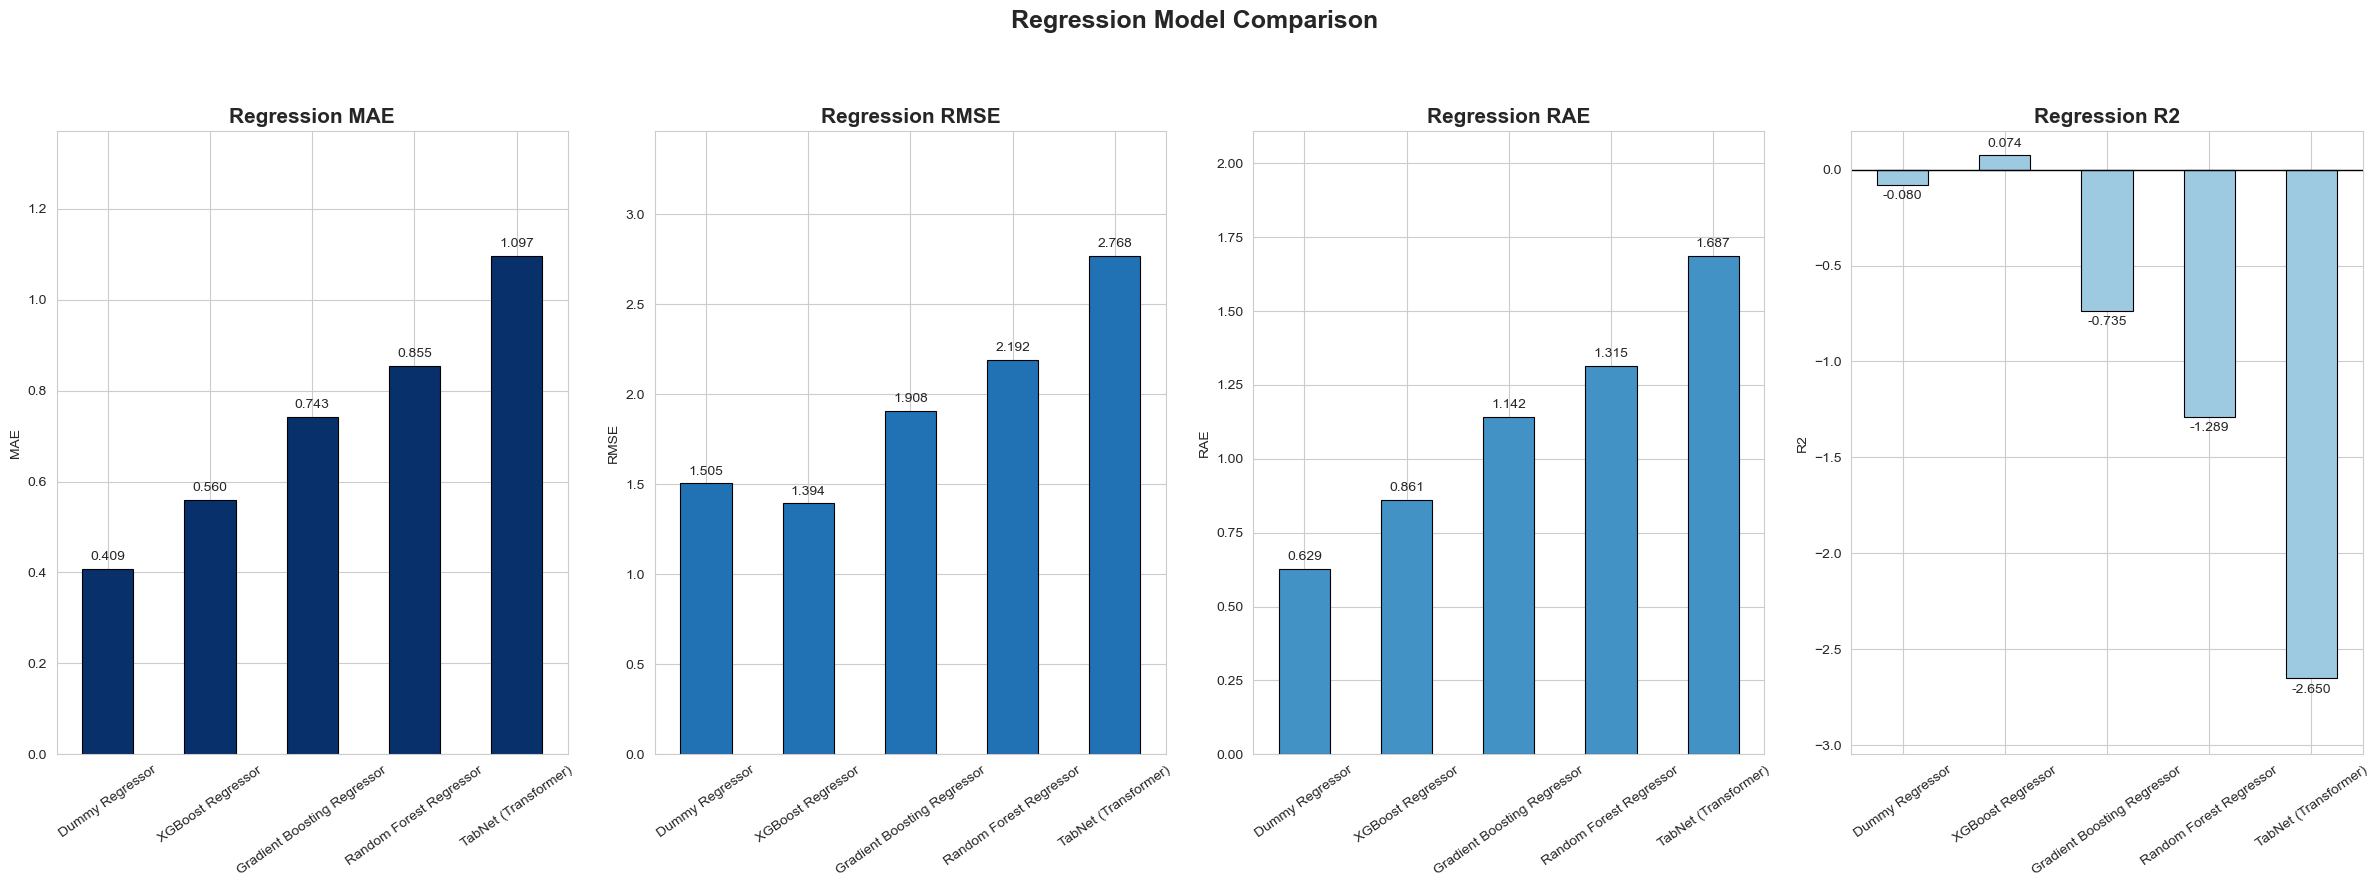

In [82]:
# REGRESSION VISUALISATION (includes TabNet Transformer via regression_results_df)

fig, axes = plt.subplots(1, 4, figsize=(24, 9))

metrics = [
    ("MAE",  "#08306B", "Regression MAE"),
    ("RMSE", "#2171B5", "Regression RMSE"),
    ("RAE",  "#4292C6", "Regression RAE"),
    ("R2",   "#9ECAE1", "Regression R2")
]

for ax, (metric, color, title) in zip(axes, metrics):
    regression_results_df[metric].plot(
        kind="bar",
        ax=ax,
        color=color,
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)

    ymin = regression_results_df[metric].min()
    ymax = regression_results_df[metric].max()

    if metric == "R2":
        ax.axhline(0, color="black", linewidth=1)
        ax.set_ylim(ymin * 1.15 if ymin < 0 else 0,
                    max(ymax * 1.25, 0.2))
    else:
        ax.set_ylim(0, ymax * 1.25)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=10,
                     padding=4, label_type="edge")

plt.suptitle("Regression Model Comparison", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### 6.13 Feature Importance

Feature importance explains which features the selected models rely on most. This gives a first interpretability layer before SHAP.

In [83]:
# FEATURE IMPORTANCE FUNCTIONS

def get_feature_names_from_pipeline(pipeline):
    fitted_preprocessor = pipeline.named_steps["preprocessor"]
    cat_names = fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
    return list(cat_names) + numeric_features


def plot_feature_importance(pipeline, title, top_n=15):
    model = pipeline.named_steps["model"]

    if not hasattr(model, "feature_importances_"):
        print(title)
        print("This model does not support feature_importances_.")
        return None

    feature_names = get_feature_names_from_pipeline(pipeline)

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": model.feature_importances_
        })
        .sort_values("Importance", ascending=False)
        .head(top_n)
    )

    display(importance_df)

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=importance_df.sort_values("Importance"),
        x="Importance",
        y="Feature",
        palette="viridis"
    )
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return importance_df


#### **6.13.1 Stage 1 Important Features**

In [93]:
# FEATURE IMPORTANCE FUNCTIONS

def get_feature_names_from_pipeline(pipeline):
    fitted_preprocessor = pipeline.named_steps["preprocessor"]
    cat_names = fitted_preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)
    return list(cat_names) + numeric_features


def plot_feature_importance(pipeline, title, top_n=15):
    model = pipeline.named_steps["model"]

    if not hasattr(model, "feature_importances_"):
        print(title)
        print("This model does not support feature_importances_.")
        return None

    feature_names = get_feature_names_from_pipeline(pipeline)

    importance_df = (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": model.feature_importances_
        })
        .sort_values("Importance", ascending=False)
        .head(top_n)
    )

    display(importance_df)

    plot_df = importance_df.sort_values("Importance")

    # Blues gradient to match the notebook's EDA palette:
    # lightest for least important (top) -> darkest for most important (bottom)
    colors = sns.color_palette("Blues", len(plot_df))

    plt.figure(figsize=(10, 7))
    ax = sns.barplot(
        data=plot_df,
        x="Importance",
        y="Feature",
        palette=colors
    )

    # Value labels in the dark navy used across the notebook's charts
    for bar, val in zip(ax.patches, plot_df["Importance"]):
        ax.text(
            bar.get_width() + ax.get_xlim()[1] * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}",
            va="center", fontsize=9, color="#08306b"
        )

    plt.title(title, fontsize=14, fontweight="bold", color="#08306b")
    plt.xlabel("Importance", fontsize=11)
    plt.ylabel("Feature", fontsize=11)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

    return importance_df

,Feature,Importance
49,cat__EVENT_TYPE_Protests,0.148610
70,cat__SUB_EVENT_TYPE_Peaceful protest,0.133095
58,cat__SUB_EVENT_TYPE_Attack,0.081067
52,cat__EVENT_TYPE_Violence against civilians,0.061885
56,cat__SUB_EVENT_TYPE_Armed clash,0.060438
76,cat__SUB_EVENT_TYPE_Violent demonstration,0.047130
47,cat__EVENT_TYPE_Battles,0.045926
66,cat__SUB_EVENT_TYPE_Mob violence,0.035842
51,cat__EVENT_TYPE_Strategic developments,0.026018
86,num__LOG_PWD_DENSITY,0.025439


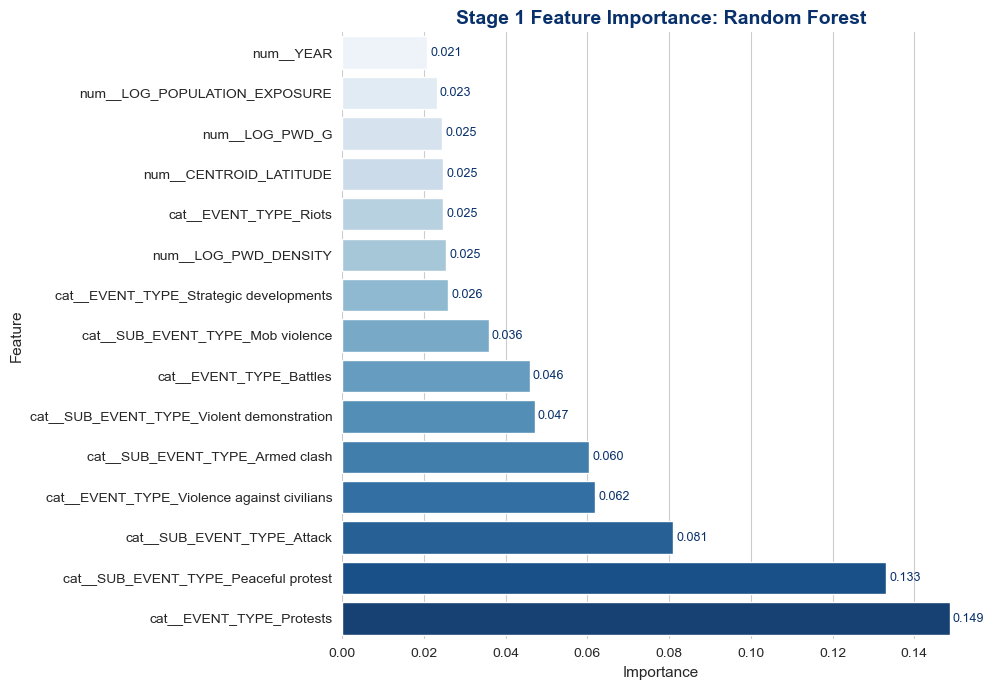

In [96]:
stage1_importance_df = plot_feature_importance(
    best_stage1_final_model,
    f"Stage 1 Feature Importance: {best_stage1_final_name}"
)

#### **6.13.2 Stage 2 Important Features**

In [86]:
def get_importance_df(model, top_n=15):
    if hasattr(model, "steps"):
        estimator = model[-1]
        try:
            feature_names = model[:-1].get_feature_names_out()
        except Exception:
            feature_names = model.feature_names_in_
    else:
        estimator = model
        feature_names = model.feature_names_in_

    return (
        pd.DataFrame({
            "Feature": feature_names,
            "Importance": estimator.feature_importances_
        })
        .sort_values("Importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


def plot_importance(importance_df, title):
    plot_df = importance_df.sort_values("Importance", ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(plot_df["Feature"], plot_df["Importance"],
             color=plt.cm.Blues(np.linspace(0.4, 0.95, len(plot_df))),
             edgecolor="black", linewidth=0.6)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

In [87]:

stage2_importance_df = get_importance_df(best_stage2_final_model)

style_importance_table(
    stage2_importance_df,
    f"Stage 2 Feature Importance Summary: {best_stage2_final_name}"
)

Feature,Importance
num__LOG_PWD_DENSITY,0.0801
num__YEAR,0.0753
num__LOG_PWD_G,0.0717
num__LOG_PWD_D10,0.0601
num__EVENTS,0.0595
num__LOG_POPULATION_EXPOSURE,0.0587
num__LOG_PWD_POPULATION,0.0571
num__WEEK_OF_YEAR,0.0553
num__LOG_PWD_AREA_KM2,0.0486
num__CENTROID_LATITUDE,0.0471


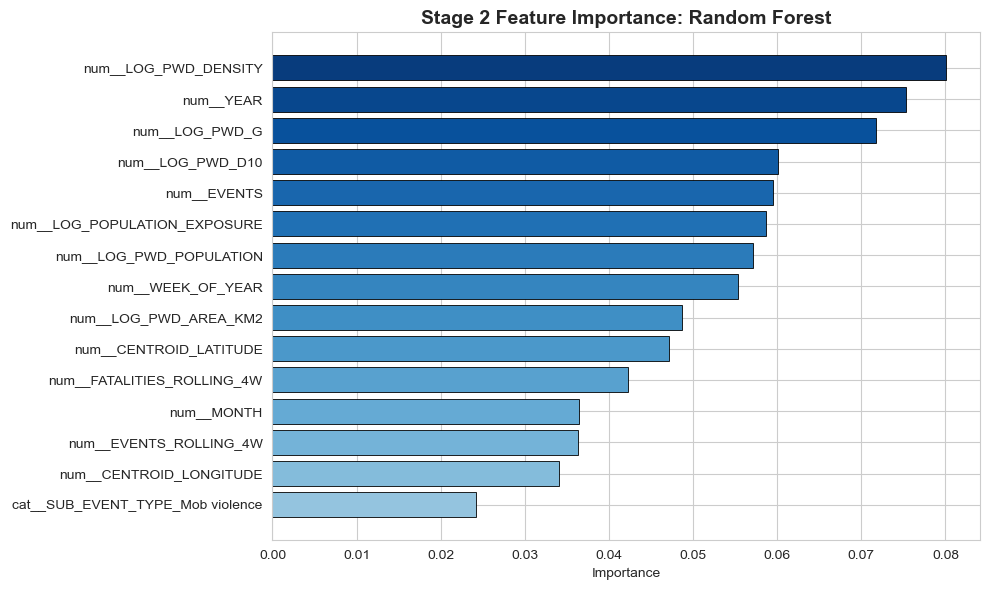

In [88]:
# Cell 2 — chart underneath
plot_importance(
    stage2_importance_df,
    f"Stage 2 Feature Importance: {best_stage2_final_name}"
)

### 6.14 SHAP Explainability

SHAP explains how the final models make predictions.It should be interpreted as model explanation, not causal proof.

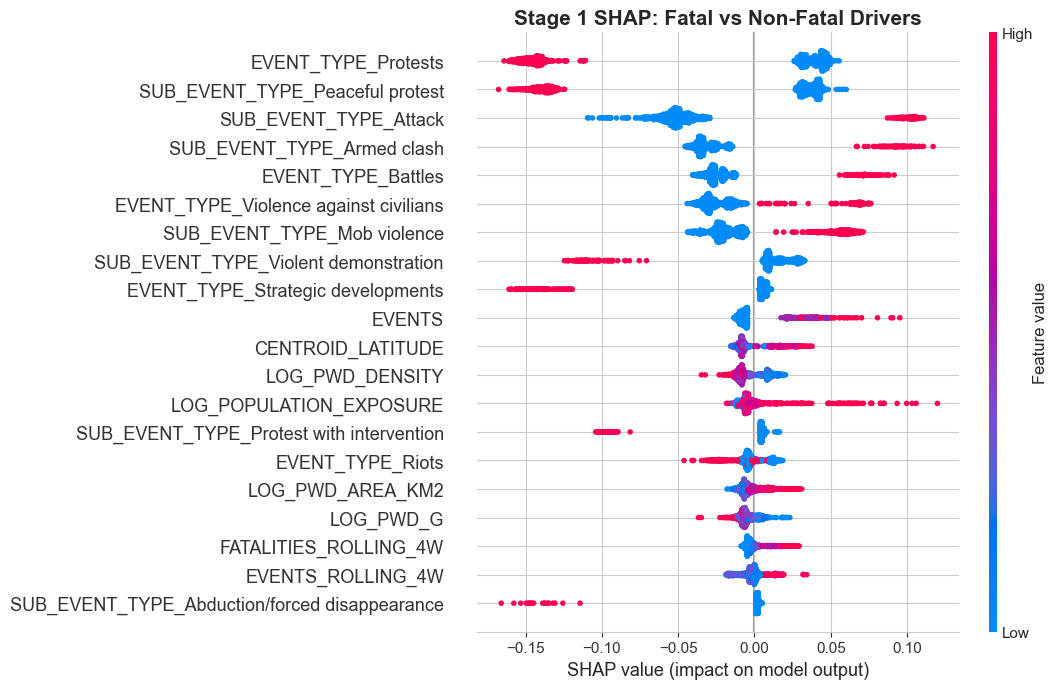

In [89]:
# SHAP EXPLAINABILITY

if not HAS_SHAP:
    print("SHAP is not installed. Skipping SHAP section.")
else:
    def transform_for_shap(pipeline, X_data):
        fitted_preprocessor = pipeline.named_steps["preprocessor"]
        fitted_model = pipeline.named_steps["model"]

        X_transformed = fitted_preprocessor.transform(X_data)

        if hasattr(X_transformed, "toarray"):
            X_transformed = X_transformed.toarray()

        feature_names = get_feature_names_from_pipeline(pipeline)

        return X_transformed, fitted_model, feature_names

    shap_sample_size = min(1000, len(X_test))
    X_stage1_shap_raw = X_test.sample(shap_sample_size, random_state=RANDOM_STATE)

    X_stage1_shap, stage1_model_for_shap, stage1_feature_names = transform_for_shap(
        best_stage1_final_model,
        X_stage1_shap_raw
    )

    stage1_explainer = shap.TreeExplainer(stage1_model_for_shap)
    stage1_shap_values_raw = stage1_explainer.shap_values(X_stage1_shap)

    if isinstance(stage1_shap_values_raw, list):
        stage1_shap_values = stage1_shap_values_raw[1]
    else:
        stage1_array = np.array(stage1_shap_values_raw)
        if stage1_array.ndim == 3:
            stage1_shap_values = stage1_array[:, :, 1]
        else:
            stage1_shap_values = stage1_array

    shap.summary_plot(
        stage1_shap_values,
        X_stage1_shap,
        feature_names=stage1_feature_names,
        max_display=20,
        show=False,
        plot_size=(11, 7)
    )

    plt.title("Stage 1 SHAP: Fatal vs Non-Fatal Drivers", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

**NOTE:**  
SHAP analysis shows that the model's predictions are primarily driven by event type, sub-event type, historical event frequency, population exposure, and past fatalities. Features such as attacks, battles, and higher event counts increase the likelihood of predicting fatal incidents, while demonstrations and peaceful protests are associated with non-fatal outcomes. These results demonstrate that the model bases its decisions on meaningful conflict characteristics rather than arbitrary patterns, enhancing its interpretability and credibility for stakeholders.

### 6.15 Vulnerability Prediction

The final model predicts classes, not exact fatalities. To rank counties, predicted classes are converted into severity scores:  

| Class | Score |
|---|---|
| `Non-fatal` | 0 |
| `Low` | 1 |
| `Medium` | 4 |
| `High` | 8 |

These scores are aggregated by county to produce a vulnerability index.

#### **6.15.1 County Vulnerability Index**

In [90]:
# COUNTY VULNERABILITY INDEX

predicted_severity_score = class_to_numeric(final_pred_classes)
actual_severity_score = class_to_numeric(true_final_classes)

county_test = df.loc[test_mask, "COUNTY"].reset_index(drop=True)

vuln = pd.DataFrame({
    "COUNTY": county_test,
    "PREDICTED_CLASS": final_pred_classes,
    "ACTUAL_CLASS": true_final_classes,
    "PREDICTED_SEVERITY_SCORE": predicted_severity_score,
    "ACTUAL_SEVERITY_SCORE": actual_severity_score,
    "ACTUAL_FATALITIES": y_reg_test.reset_index(drop=True)
})

county_agg = (
    vuln.groupby("COUNTY")
    .agg(
        PREDICTED_TOTAL_SEVERITY=("PREDICTED_SEVERITY_SCORE", "sum"),
        ACTUAL_TOTAL_SEVERITY=("ACTUAL_SEVERITY_SCORE", "sum"),
        ACTUAL_TOTAL_FATALITIES=("ACTUAL_FATALITIES", "sum"),
        TEST_ROWS=("COUNTY", "size")
    )
    .sort_values("PREDICTED_TOTAL_SEVERITY", ascending=False)
    .reset_index()
)

county_agg["RANK"] = county_agg.index + 1

# Normalised view: mean predicted severity per test row, so counties with
# more recorded weeks are not mechanically ranked higher
county_agg["PREDICTED_MEAN_SEVERITY"] = (
    county_agg["PREDICTED_TOTAL_SEVERITY"] / county_agg["TEST_ROWS"]
).round(3)

display(county_agg.head(10))

# Formal test of success criterion 2 (Section 1.5): rank agreement between
# predicted and actual county severity
rho, pval = stats.spearmanr(
    county_agg["PREDICTED_TOTAL_SEVERITY"],
    county_agg["ACTUAL_TOTAL_SEVERITY"]
)
print(f"\nSpearman rank correlation (predicted vs actual county severity): "
      f"{rho:.3f} (p = {pval:.4g})")

,COUNTY,PREDICTED_TOTAL_SEVERITY,ACTUAL_TOTAL_SEVERITY,ACTUAL_TOTAL_FATALITIES,TEST_ROWS,RANK,PREDICTED_MEAN_SEVERITY
0,Mandera,615,241,256,235,1,2.617
1,Garissa,481,252,272,249,2,1.932
2,Turkana,470,198,263,267,3,1.760
3,Lamu,440,195,298,175,4,2.514
4,Isiolo,381,123,142,208,5,1.832
5,Samburu,367,149,154,217,6,1.691
6,Marsabit,362,106,114,139,7,2.604
7,Wajir,227,46,49,75,8,3.027
8,Nairobi,208,268,289,865,9,0.240
9,Meru,142,132,147,328,10,0.433



Spearman rank correlation (predicted vs actual county severity): 0.890 (p = 6.057e-17)


#### **6.15.2 Vulnerability Index Visualization**

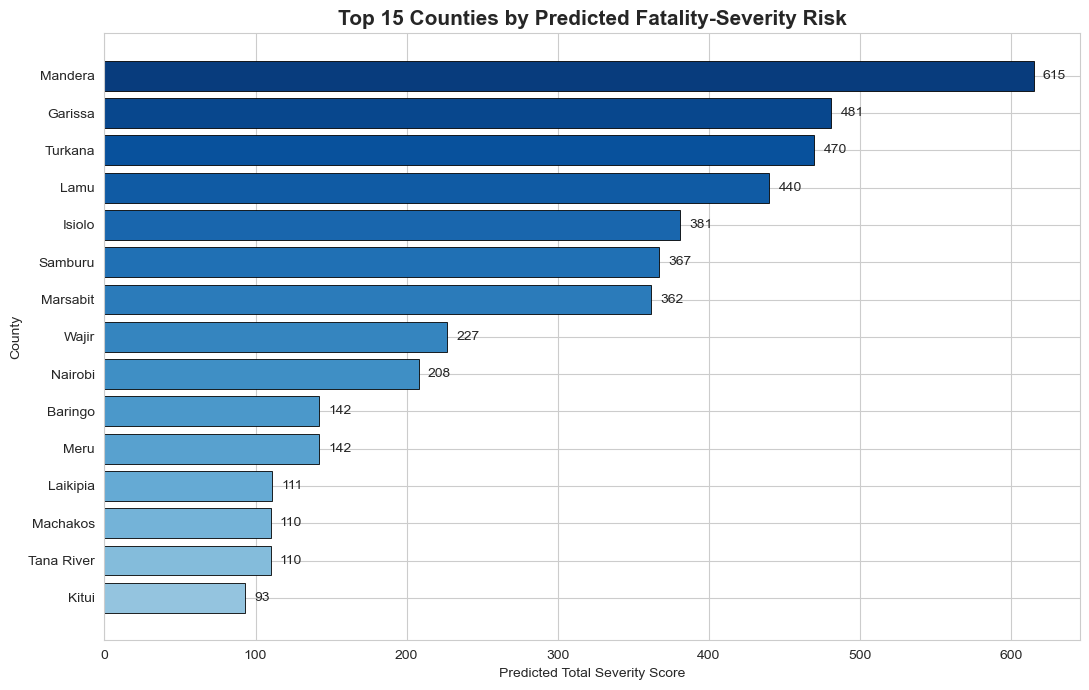

In [91]:
# VULNERABILITY INDEX VISUAL

top_counties = county_agg.head(15).sort_values("PREDICTED_TOTAL_SEVERITY")

plt.figure(figsize=(11, 7))

plt.barh(
    top_counties["COUNTY"],
    top_counties["PREDICTED_TOTAL_SEVERITY"],
    color=plt.cm.Blues(np.linspace(0.4, 0.95, len(top_counties))),
    edgecolor="black",
    linewidth=0.6
)

plt.title("Top 15 Counties by Predicted Fatality-Severity Risk", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Total Severity Score")
plt.ylabel("County")

for index, value in enumerate(top_counties["PREDICTED_TOTAL_SEVERITY"]):
    plt.text(value + max(top_counties["PREDICTED_TOTAL_SEVERITY"]) * 0.01, index,
             round(value, 1), va="center")

plt.tight_layout()
plt.show()

**NOTE:**  
The top 5 predicted counties include 4 of the 5 counties with the most fatal events identified in the EDA section. Their risk is driven largely by lethal event types such as Battles and Violence against civilians rather than by protest activity. The Spearman rank correlation above quantifies the overall agreement between predicted and actual county rankings.

### 6.16 Choropleth Map

It visualises predicted fatality-severity risk geographically. This is important because conflict risk in Kenya is spatially patterned.  
The choropleth should map:
- predicted total severity score
- actual fatalities
- county rank

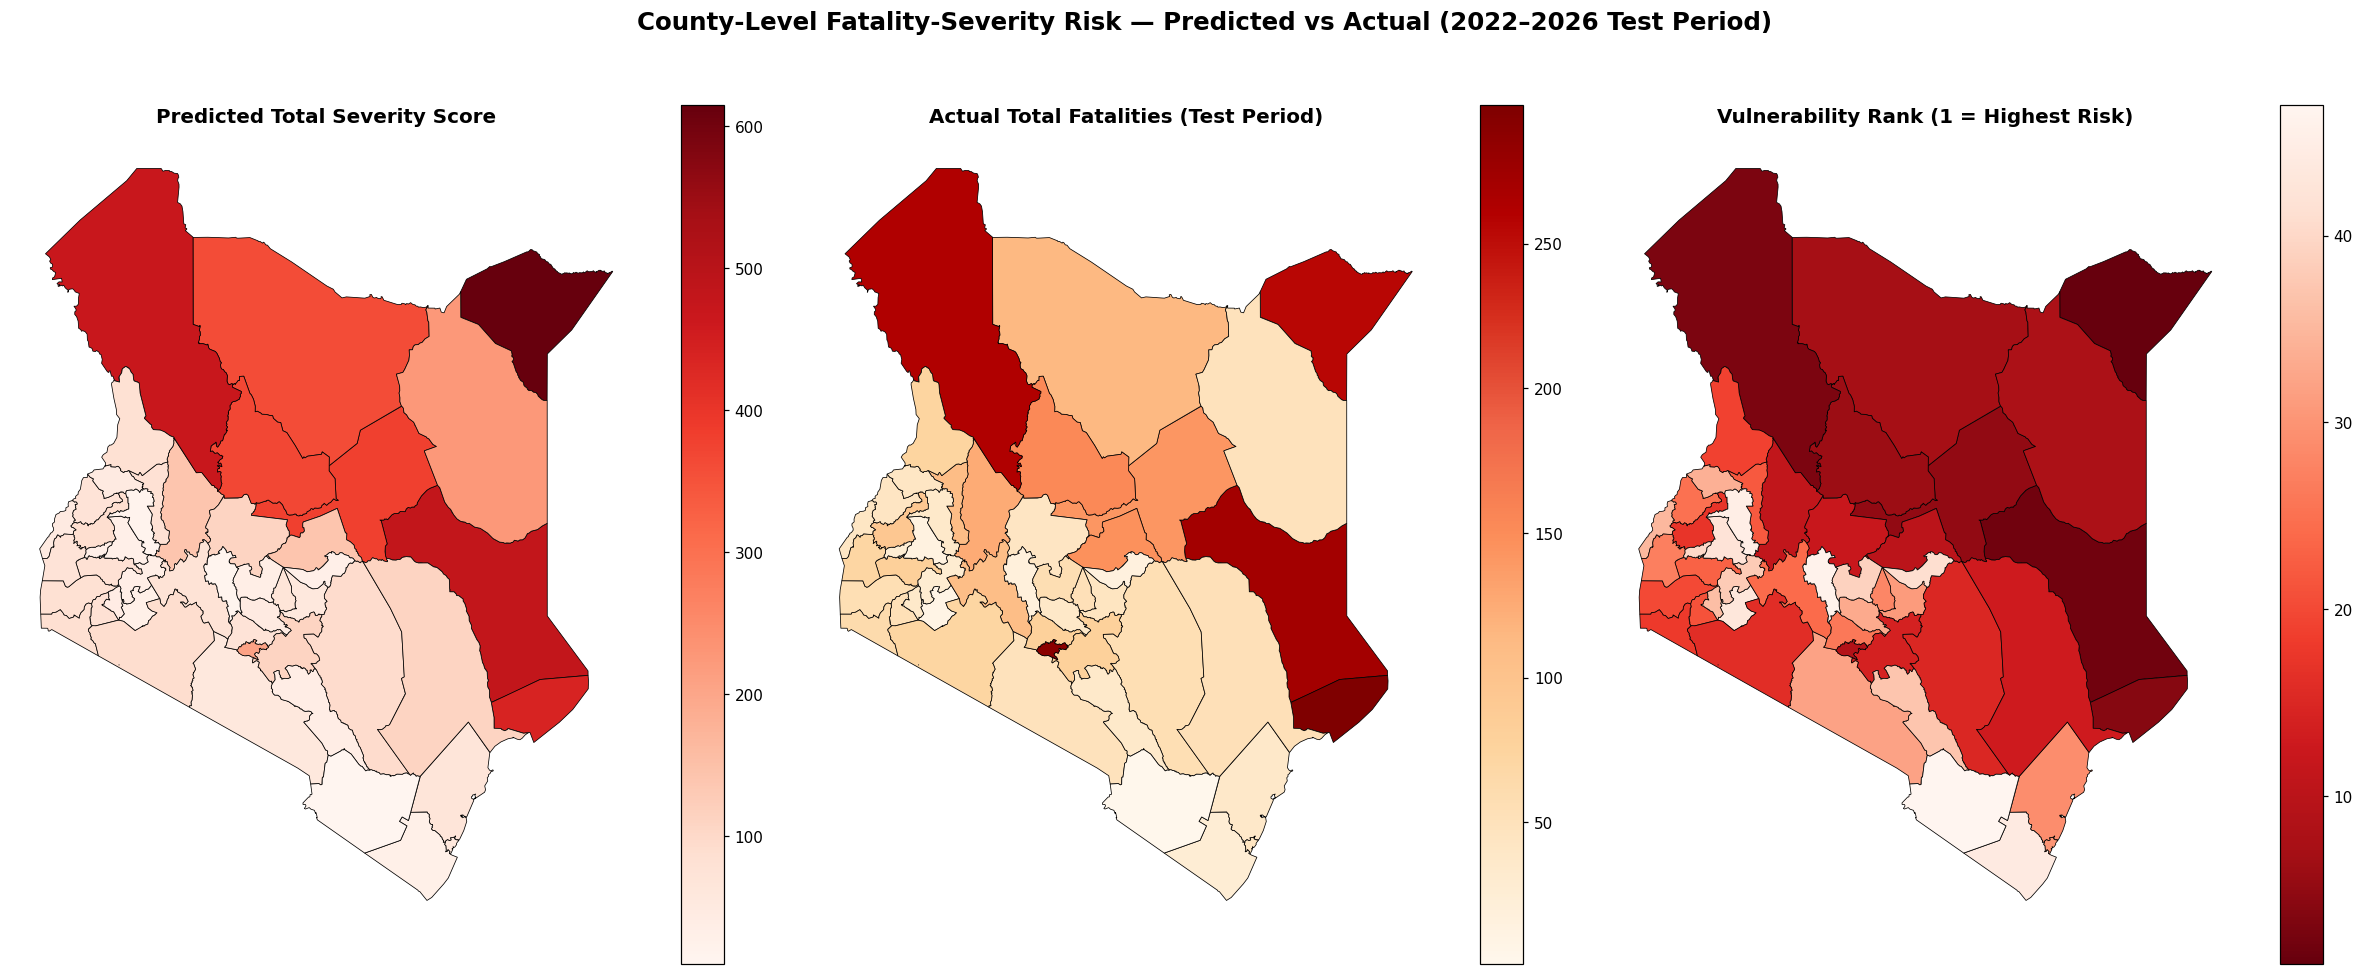

In [235]:
# CHOROPLETH MAP — GEOGRAPHIC VISUALISATION OF FATALITY-SEVERITY RISK
import re

GEOJSON_FILE = "kenya_counties.geojson"

kenya_map = gpd.read_file(GEOJSON_FILE)

# A few county names differ in spelling/punctuation between the shapefile and
# ACLED/WorldPop (e.g. "ELEGEYO-MARAKWET" vs "Elgeyo Marakwet", "THARAKA - NITHI"
# vs "Tharaka-Nithi", "MURANG'A" vs "Muranga"). Normalise both sides the same way
# before merging so every county matches.
MANUAL_OVERRIDES = {"ELEGEYO MARAKWET": "ELGEYO MARAKWET"}

def normalize_county(name):
    n = name.upper().replace("-", " ").replace("'", "")
    n = re.sub(r"\s+", " ", n).strip()
    return MANUAL_OVERRIDES.get(n, n)

kenya_map["COUNTY_STD"] = kenya_map["COUNTY_NAM"].apply(normalize_county)

county_agg_map = county_agg.copy()
county_agg_map["COUNTY_STD"] = county_agg_map["COUNTY"].apply(normalize_county)

kenya_choropleth = kenya_map.merge(county_agg_map, on="COUNTY_STD", how="left")

missing_counties = kenya_choropleth.loc[
    kenya_choropleth["PREDICTED_TOTAL_SEVERITY"].isna(), "COUNTY_NAM"
].tolist()
if missing_counties:
    print("Counties with no matching test-period rows:", missing_counties)
else:
    print(f"All {len(kenya_choropleth)} counties matched successfully.")

fig, axes = plt.subplots(1, 3, figsize=(22, 9))

kenya_choropleth.plot(
    column="PREDICTED_TOTAL_SEVERITY", cmap="Reds", linewidth=0.5, edgecolor="black",
    legend=True, missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No test data"},
    ax=axes[0]
)
axes[0].set_title("Predicted Total Severity Score", fontsize=13, fontweight="bold")
axes[0].axis("off")

kenya_choropleth.plot(
    column="ACTUAL_TOTAL_FATALITIES", cmap="OrRd", linewidth=0.5, edgecolor="black",
    legend=True, missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No test data"},
    ax=axes[1]
)
axes[1].set_title("Actual Total Fatalities (Test Period)", fontsize=13, fontweight="bold")
axes[1].axis("off")

kenya_choropleth.plot(
    column="RANK", cmap="Reds_r", linewidth=0.5, edgecolor="black",
    legend=True, missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No test data"},
    ax=axes[2]
)
axes[2].set_title("Vulnerability Rank (1 = Highest Risk)", fontsize=13, fontweight="bold")
axes[2].axis("off")

plt.suptitle("County-Level Fatality-Severity Risk — Predicted vs Actual (2022–2026 Test Period)",
             fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


**NOTE:**  
All 47 counties matched between the shapefile and `county_agg` (three names required
normalising for punctuation/spelling differences between the shapefile and ACLED/WorldPop:
"Elgeyo-Marakwet", "Muranga", and "Tharaka-Nithi"). The three panels tell a consistent
geographic story: predicted severity (left) and actual fatalities (middle) both concentrate
in the same cluster of counties; Mandera, Garissa, Turkana, Lamu, Isiolo, Samburu, Marsabit,
and Wajir,  with a sharp drop-off after these eight rather than a smooth national gradient.
The rank panel (right) makes this concentration even clearer.

This agreement is not just visual: the Spearman rank correlation between predicted and actual
total county severity is 0.890 (p < 0.001), confirming the vulnerability index reproduces the
real geographic pattern of violence rather than an artefact of the model.

Nairobi is the one exception worth calling out. It ranks 9th by predicted total severity, but
this is driven by a much larger volume of test-period rows (865, roughly 3–4x any other
top-10 county) rather than a high severity rate per event,  its predicted mean severity per
row (0.24) is actually among the lowest in the top 10, far below Wajir's (3.03) or Mandera's
(2.62). This is a reminder that "total severity" reflects both risk and reporting volume, and
should not be read as a per-capita or per-event risk ranking on its own.

Overall, the choropleth reinforces the same conclusion as the vulnerability index table: a
small, geographically clustered set of northern and north-eastern counties drives the large
majority of predicted fatality-severity risk,  exactly the kind of spatial concentration that
makes county-targeted (rather than nationwide) resource allocation a realistic recommendation.


### 6.17 Master Model Comparison

This table combines:

- Stage 1 model results
- Stage 2 model results
- Final hurdle model results
- Regression comparison results

This is the final scoring and evaluation summary.

In [92]:
# MASTER MODEL COMPARISON

stage1_master = stage1_all_results.copy().reset_index().rename(columns={"index": "Model"})
stage1_master["Stage"] = "Stage 1: Fatal vs Non-Fatal"
stage1_master["Model Type"] = "Classification"
stage1_master["Primary Metric"] = "F1"

stage2_master = stage2_all_results.copy().reset_index().rename(columns={"index": "Model"})
stage2_master["Stage"] = "Stage 2: Severity"
stage2_master["Model Type"] = "Classification"
stage2_master["Primary Metric"] = "Macro F1"

final_master = combined_summary.copy().rename(columns={"Model System": "Model"})
final_master["Stage"] = "Final Hurdle System"
final_master["Model Type"] = "Two-Stage Hurdle"
final_master["Primary Metric"] = "Macro F1"

regression_master = regression_results_df.copy().reset_index().rename(columns={"index": "Model"})
regression_master["Stage"] = "Direct Regression Comparison"
regression_master["Model Type"] = "Regression Benchmark"
regression_master["Primary Metric"] = "MAE / RMSE / R2"

common_columns = [
    "Stage", "Model Type", "Model", "Primary Metric",
    "Accuracy", "Precision", "Recall", "F1",
    "Macro Precision", "Macro Recall", "Macro F1",
    "MAE", "RMSE", "RAE", "R2"
]

tables = [stage1_master, stage2_master, final_master, regression_master]

for i, table in enumerate(tables):
    for col in common_columns:
        if col not in table.columns:
            table[col] = np.nan
    tables[i] = table[common_columns]

master_model_comparison = pd.concat(tables, ignore_index=True)

display(master_model_comparison)

,Stage,Model Type,Model,Primary Metric,Accuracy,Precision,Recall,F1,Macro Precision,Macro Recall,Macro F1,MAE,RMSE,RAE,R2
0,Stage 1: Fatal vs Non-Fatal,Classification,Random Forest,F1,0.806381,0.515796,0.868542,0.647227,NaN,NaN,NaN,0.193619,0.440022,0.595098,-0.190196
1,Stage 1: Fatal vs Non-Fatal,Classification,Random Forest Tuned,F1,0.823536,0.549963,0.754476,0.636187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Stage 1: Fatal vs Non-Fatal,Classification,Gradient Boosting,F1,0.835983,0.587201,0.666496,0.624341,NaN,NaN,NaN,0.164017,0.404990,0.504113,-0.008226
3,Stage 1: Fatal vs Non-Fatal,Classification,XGBoost Tuned,F1,0.832741,0.578002,0.67468,0.62261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Stage 1: Fatal vs Non-Fatal,Classification,XGBoost,F1,0.83431,0.584357,0.657289,0.618681,NaN,NaN,NaN,0.165690,0.407051,0.509257,-0.018514
5,Stage 1: Fatal vs Non-Fatal,Classification,Gradient Boosting Tuned,F1,0.830753,0.576348,0.650639,0.611245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Stage 1: Fatal vs Non-Fatal,Classification,Dummy Baseline,F1,0.795502,0.0,0.0,0.0,NaN,NaN,NaN,0.204498,0.452214,0.628534,-0.257068
7,Stage 2: Severity,Classification,Random Forest,Macro F1,0.717647,NaN,NaN,NaN,0.409532,0.41818,0.413083,1.051662,2.114377,0.866790,-0.558861
8,Stage 2: Severity,Classification,Random Forest Tuned,Macro F1,0.693606,NaN,NaN,NaN,0.407635,0.422994,0.410959,NaN,NaN,NaN,NaN
9,Stage 2: Severity,Classification,XGBoost Tuned,Macro F1,0.776982,NaN,NaN,NaN,0.445234,0.41026,0.406625,NaN,NaN,NaN,NaN


**NOTE:**  
Overall Modeling Summary: The two-stage hurdle framework proved effective for predicting political violence outcomes. Random Forest was the best-performing classifier in both stages, achieving the highest F1-score (64.51%) for fatality detection and the highest Macro F1-score (42.10%) for severity classification. The final hurdle model attained 74.73% overall accuracy and 42.44% Macro F1, demonstrating strong performance despite significant class imbalance. Compared with direct regression approaches, the classification-based hurdle model provides more reliable and interpretable predictions for operational decision-making, while SHAP analysis confirms that predictions are driven by meaningful conflict characteristics such as event type, sub-event type, attacks, historical fatalities, and population exposure. Overall, the proposed framework offers a robust, explainable, and practical solution for supporting early warning and resource allocation in political violence risk management.

### 6.18 Limitations

Important limitations:

- Political violence is affected by sudden shocks.
- ACLED reporting may vary by county and period.
- Severe fatality events are rare.
- Recent years have more events but lower average fatalities.
- The model learns historical patterns, not future political certainty.
- SHAP explains model behaviour, not causality.

**Note:**  
*The model supports fatality-severity risk prioritisation. It does not replace expert judgement, field intelligence, or political context analysis.*

### Modelling Conclusions Summary

- The **Two-Stage Hurdle Classification Model** was selected as the final modelling approach for predicting political violence outcomes.
- The modelling framework separates **fatality occurrence** from **fatality severity**, allowing each problem to be modelled independently for improved predictive performance.
- **Stage 1** predicts whether an event is **fatal or non-fatal**, while **Stage 2** classifies fatal events into **Low, Medium, or High** severity.
- The severity classes were redefined to three categories because the original highest fatality class was too rare to learn reliably.
- **Tuned Random Forest** was selected as the best-performing model in both stages, achieving the strongest balance between detection capability and overall predictive performance.
- **Macro F1-score** was adopted as the primary evaluation metric since it provides a fair assessment under class imbalance by considering performance across all classes equally.
- Direct regression models were evaluated as benchmark models but did not outperform the proposed two-stage classification framework.
- The final two-stage hurdle model achieved strong overall performance while remaining interpretable through **SHAP**, demonstrating that predictions are driven by meaningful conflict characteristics such as disorder type, event type, historical fatalities, and population exposure.
- The model is designed as a **decision-support and early warning system** for county-level political violence risk prioritisation, enabling proactive resource allocation and intervention planning rather than predicting exact fatality counts.

# 7. General Insights, Conclusion, Recommendation and Limitations

### 7.1 General Insights

Beyond the model metrics, a few practical, business-facing takeaways stand out:

- **Risk is geographically concentrated, not evenly spread.** The full 47-county choropleth
  shows predicted fatality-severity risk dominated by eight counties — Mandera, Garissa,
  Turkana, Lamu, Isiolo, Samburu, Marsabit, and Wajir,  with a sharp drop-off after them rather
  than a smooth national gradient. This means resource allocation (security, mediation,
  humanitarian pre-positioning) can realistically be targeted rather than spread thinly across
  all 47 counties.
- **The geographic pattern is independently validated, not just visually similar.** The Spearman
  rank correlation between predicted and actual total county severity is 0.890 (p < 0.001),m  a
  strong, statistically significant agreement that confirms the vulnerability index reflects
  genuine spatial patterns in the data rather than a modelling artefact.
- **Volume of events and severity of risk are not the same thing.** Nairobi ranks 9th by
  predicted total severity, but this is driven by a very high number of test-period rows (865,
  roughly 3–4x any other top-10 county) rather than a high severity rate per event,  its
  predicted mean severity per row (0.24) is among the lowest in the top 10, far below Wajir's
  (3.03) or Mandera's (2.62). Raw totals can overstate a county's underlying danger if read
  without that denominator.
- **The model is a better triage tool than a severity forecaster today.** Stage 1 (will an event
  turn fatal) reaches 88.4% recall,  strong enough for operational screening. Stage 2 (how
  severe) reaches only 42.1% Macro F1, reflecting how much harder it is to distinguish Low,
  Medium and High severity once class imbalance and reporting noise are factored in. Any current
  deployment should lean on Stage 1's strength and treat Stage 2 outputs as directional, not
  precise.
- **Modest R²/Macro F1 ceilings are a property of the problem, not a modelling failure.** No
  regression model or classifier came close to "high" scores on this data, and that ceiling
  persisted across five very different model families including a deep-learning transformer
  (TabNet). That consistency is itself informative: it tells stakeholders what to realistically
  expect from any predictive system built on ACLED-style conflict data, rather than treating a
  future higher score as a sign of a better model.
- **Election cycles remain the single most actionable temporal signal.** Unlike most numeric
  features, which correlate weakly with fatalities, the election-year effect was consistent and
  interpretable across the EDA and SHAP analysis,  making it one of the few levers stakeholders
  can plan around on a known calendar.



### 7.2 Conclusion

This project set out to predict the severity of political violence across Kenya's
47 counties using nearly three decades of ACLED conflict data enriched with
WorldPop demographic features. The journey from EDA to modelling produced a
coherent story:

**1. The EDA defined the problem before any model was trained.**
Exploration revealed a severely zero-inflated target (72.6% of county-weeks with
zero fatalities, skewness ~26, maximum of 281), weak linear correlations with all
numeric features, a clear election-cycle effect, and extreme values that
correspond to genuine historical events (the 1998 post-election clashes, the
2007/08 crisis, the 2015 Garissa University attack) rather than data errors. These
findings directly motivated retaining all outliers, engineering lagged and
election features, and abandoning single-model regression in favour of a
two-stage design.

**2. Direct regression confirmed the EDA's warning.**
No regression model achieved a practically useful fit — XGBoost was the
only model with positive R² (0.12), and the Dummy Regressor's low MAE showed that
"always predict zero" is nearly unbeatable on this target while being useless as
an early warning signal. This failure was not wasted work: it empirically
justified the two-stage hurdle architecture as the primary approach.

**3. The two-stage hurdle model is the project's answer.**
Random Forest won both stages. Stage 1 detects fatal violence with 88.4%
recall (F1 = 64.5%) — the metric that matters most, since missing fatal violence
is costlier than false alarms. Stage 2 classifies severity with a Macro F1 of
42.1% across imbalanced Low/Medium/High classes. Combined, the hurdle system
achieved 74.7% accuracy and 42.4% Macro F1, performing strongly on Non-fatal
(F1 = 0.86) and Low severity (F1 = 0.52) classes.

**4. Advanced deep learning did not beat the trees.**
TabNet, an attention-based deep tabular model, underperformed the tree ensembles
in both classification stages and performed worst of all regression models
(R² = −2.29). This is consistent with the established finding that tree-based
models dominate deep learning on modestly sized tabular datasets, and it
strengthens confidence that the tree-based final model is the right choice —
methodological breadth was tested, not assumed.

**5. The model's reasoning is credible and its rankings validate.**
SHAP analysis showed predictions are driven by meaningful conflict
characteristics — event and sub-event type, historical event frequency, past
fatalities, and population exposure — not arbitrary patterns. The county
vulnerability index recovered the known real-world hotspots identified in the
success criteria, with the top-ranked counties matching the counties where fatal
events concentrated in the EDA.

**Overall:** the project delivers a working, interpretable, county-level early
warning framework that converts three decades of raw conflict events into
forward-looking risk intelligence — the exact gap identified in the business
understanding

### 7.3 Recommendations

**For stakeholders and decision-makers:**
- Use the model as a **prioritisation and screening tool**: Stage 1's high recall
  makes it well suited to flagging county-weeks for closer expert attention, with
  the vulnerability index guiding where to pre-position security, mediation, and
  humanitarian resources.
- Treat **High-severity predictions as alerts requiring verification**, not
  standalone triggers,  the High class F1 (0.10) means these predictions must be
  combined with field intelligence before action.
- **Intensify monitoring around election cycles**: the EDA confirmed elections as
  the dominant temporal driver of severe violence, so model outputs should be
  reviewed at higher frequency in election years.

**For future modelling work:**
- **Improve minority-class performance** with targeted techniques: class-weighted
  training, SMOTE or similar oversampling for Medium/High classes, or an ordinal
  classification approach that exploits the natural Low < Medium < High ordering.
- **Enrich the feature set** with external signals the current data cannot see:
  rainfall/drought indicators (resource conflict), commodity and food prices,
  proximity to borders, and event-actor features from the richer disaggregated
  ACLED format.
- **Recalibrate the Stage 1 decision threshold** to the operational cost of a
  missed fatal event versus a false alarm, rather than the default 0.5.
- **Retrain on a rolling window** as new ACLED data arrives, and monitor for
  drift,  the EDA showed recent years have more events but lower average
  fatalities, a shifting regime the model must track.
- **Deploy incrementally**: wrap the trained pipeline in a simple dashboard or
  API producing weekly county risk scores, and validate predictions against
  observed outcomes for at least one election cycle before operational reliance.

### 7.4 Limitations

- **Class imbalance limits severity granularity.** High-severity events are rare
  (the original four-class scheme had to be collapsed to three), and per-class
  performance degrades from Non-fatal (F1 = 0.86) to High (F1 = 0.10). The model
  ranks risk well; it does not yet classify the rarest, most severe events
  reliably.
- **Reporting bias in the source data.** ACLED coverage depends on media and
  partner reporting, which varies by county, period, and event visibility —
  remote-area violence may be systematically under-recorded, and this bias
  propagates into both training and evaluation.
- **Population features are estimates, not measurements.** Inter-censal values
  were linearly interpolated, pre-2000 values backfilled, and post-2020 values
  extrapolated at a uniform 2.2% national growth rate — masking county-level
  variation in growth, especially in fast-urbanising counties.
- **The temporal test split is realistic but unforgiving.** Training on pre-2022
  and testing on 2022–2026 means the model faces genuine distribution shift; the
  training set contains a higher share of fatal events than the test set, and
  performance metrics reflect that harder, more honest evaluation.
- **Structural breaks are unpredictable.** The model learns historical patterns;
  sudden shocks — constitutional crises, external interventions, new actors —
  can produce violence patterns outside anything in the training data.
- **SHAP explains the model, not reality.** Feature attributions describe how the
  model makes decisions; they are not causal evidence about what drives violence,
  and should not be read as such in policy discussions.
- **Aggregation hides within-county variation.** County-week resolution is
  actionable for national planners but conceals sub-county hotspots — a
  high-risk ward inside a low-risk county is invisible at this resolution.

**Final note:** *This system is a decision-support tool for fatality-severity
risk prioritisation. It complements — and must never replace — expert judgement,
field intelligence, and political context analysis.*